In [1]:
# 检查GPU是否可用
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import json
import os

print("PyTorch版本:", torch.__version__)
print("CUDA是否可用:", torch.cuda.is_available())
print("GPU型号:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "无GPU")

PyTorch版本: 2.8.0+cu126
CUDA是否可用: True
GPU型号: Tesla T4


In [3]:
!git clone https://github.com/chengyangfu/pytorch-vgg-cifar10.git

Cloning into 'pytorch-vgg-cifar10'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 67 (delta 28), reused 63 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 211.79 KiB | 35.30 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [4]:
%cd pytorch-vgg-cifar10

# 查看代码结构
!ls -la

/content/pytorch-vgg-cifar10
total 276
drwxr-xr-x 3 root root   4096 Oct 22 04:10 .
drwxr-xr-x 1 root root   4096 Oct 22 04:10 ..
drwxr-xr-x 8 root root   4096 Oct 22 04:10 .git
-rw-r--r-- 1 root root   1070 Oct 22 04:10 LICENSE
-rw-r--r-- 1 root root  10049 Oct 22 04:10 main.py
-rw-r--r-- 1 root root  87771 Oct 22 04:10 plot.ipynb
-rw-r--r-- 1 root root   1004 Oct 22 04:10 README.md
-rw-r--r-- 1 root root     18 Oct 22 04:10 requirements.txt
-rwxr-xr-x 1 root root    539 Oct 22 04:10 run.sh
-rw-r--r-- 1 root root 146742 Oct 22 04:10 vgg_plot.png
-rw-r--r-- 1 root root   2962 Oct 22 04:10 vgg.py


In [5]:
# 在Colab中下载预训练模型（使用GPU版本）
!wget http://www.cs.unc.edu/~cyfu/cifar10/model_best.pth.tar

# 检查文件是否下载成功
!ls -la model_best.pth.tar

--2025-10-22 04:13:49--  http://www.cs.unc.edu/~cyfu/cifar10/model_best.pth.tar
Resolving www.cs.unc.edu (www.cs.unc.edu)... 152.2.131.128
Connecting to www.cs.unc.edu (www.cs.unc.edu)|152.2.131.128|:80... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-22 04:13:49 ERROR 404: Not Found.

ls: cannot access 'model_best.pth.tar': No such file or directory


In [7]:
# 3. 下载预训练模型
!wget http://www.cs.unc.edu/~cyfu/cifar10/model_best.pth.tar
print("预训练模型下载完成！")

--2025-10-22 04:18:57--  http://www.cs.unc.edu/~cyfu/cifar10/model_best.pth.tar
Resolving www.cs.unc.edu (www.cs.unc.edu)... 152.2.131.128
Connecting to www.cs.unc.edu (www.cs.unc.edu)|152.2.131.128|:80... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-22 04:18:58 ERROR 404: Not Found.

预训练模型下载完成！


In [8]:
# 4. 测试预训练模型性能（作为基准）
!python main.py --resume=./model_best.pth.tar -e
print("基准测试完成！")

  File "/content/pytorch-vgg-cifar10/main.py", line 171
    input = input.cuda(async=True)
                       ^^^^^
SyntaxError: invalid syntax
基准测试完成！


In [10]:
# 1. 安装和导入必要的库
!pip install torch torchvision matplotlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import json
import os

print("环境准备完成！")
print("GPU可用:", torch.cuda.is_available())

环境准备完成！
GPU可用: True


In [13]:
# 检查目录结构
!ls -la
!ls models/

total 284
drwxr-xr-x 3 root root   4096 Oct 22 04:17 .
drwxr-xr-x 1 root root   4096 Oct 22 04:21 ..
drwxr-xr-x 8 root root   4096 Oct 22 04:10 .git
-rw-r--r-- 1 root root   1070 Oct 22 04:10 LICENSE
-rw-r--r-- 1 root root  10049 Oct 22 04:10 main.py
-rw-r--r-- 1 root root   5398 Oct 22 04:16 optimizer_comparison.py
-rw-r--r-- 1 root root  87771 Oct 22 04:10 plot.ipynb
-rw-r--r-- 1 root root   1004 Oct 22 04:10 README.md
-rw-r--r-- 1 root root     18 Oct 22 04:10 requirements.txt
-rwxr-xr-x 1 root root    539 Oct 22 04:10 run.sh
-rw-r--r-- 1 root root 146742 Oct 22 04:10 vgg_plot.png
-rw-r--r-- 1 root root   2962 Oct 22 04:10 vgg.py
ls: cannot access 'models/': No such file or directory


In [14]:
!wget http://www.cs.unc.edu/~cyfu/cifar10/model_best.pth.tar
!python main.py --resume=./model_best.pth.tar -e

--2025-10-22 04:23:17--  http://www.cs.unc.edu/~cyfu/cifar10/model_best.pth.tar
Resolving www.cs.unc.edu (www.cs.unc.edu)... 152.2.131.128
Connecting to www.cs.unc.edu (www.cs.unc.edu)|152.2.131.128|:80... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-22 04:23:17 ERROR 404: Not Found.

  File "/content/pytorch-cifar10/main.py", line 171
    input = input.cuda(async=True)
                       ^^^^^
SyntaxError: invalid syntax


In [15]:
# 首先修复main.py中的语法错误
import os

# 读取main.py文件
with open('/content/pytorch-cifar10/main.py', 'r') as f:
    content = f.read()

# 替换async=True为非阻塞模式
content = content.replace('async=True', 'non_blocking=True')

# 写回文件
with open('/content/pytorch-cifar10/main.py', 'w') as f:
    f.write(content)

print("已修复语法错误")

已修复语法错误


In [16]:
# 完整的优化器对比实验代码（从零开始训练）
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import time
import json
import sys
import matplotlib.pyplot as plt

# 确保能够导入models模块
sys.path.append('/content/pytorch-cifar10')

# 手动定义VGG模型（避免导入问题）
class VGG(nn.Module):
    def __init__(self, vgg_name):
        super(VGG, self).__init__()
        self.features = self._make_layers(cfg[vgg_name])
        self.classifier = nn.Linear(512, 10)

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        layers += [nn.AvgPool2d(kernel_size=1, stride=1)]
        return nn.Sequential(*layers)

cfg = {
    'VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG13': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG16': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'],
    'VGG19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}

# 训练函数
def train(epoch, net, trainloader, optimizer, criterion, device):
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    avg_loss = train_loss / len(trainloader)
    return avg_loss, accuracy

# 测试函数
def test(epoch, net, testloader, criterion, device):
    net.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(testloader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    avg_loss = test_loss / len(testloader)
    return avg_loss, accuracy

# 主训练函数
def run_experiment(optimizer_name, num_epochs=15):  # 减少到15个epoch以节省时间
    print(f'=== 开始 {optimizer_name} 优化器实验 ===')

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"使用设备: {device}")

    # 数据预处理
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    print("下载CIFAR-10数据集...")
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=128, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False, num_workers=2)

    # 模型 - 从零开始训练
    print("创建VGG11模型...")
    net = VGG('VGG11')
    net = net.to(device)

    # 损失函数
    criterion = nn.CrossEntropyLoss()

    # 优化器选择 - 使用不同的学习率
    if optimizer_name == 'sgd':
        optimizer = optim.SGD(net.parameters(), lr=0.01, weight_decay=5e-4)
    elif optimizer_name == 'sgd_momentum':
        optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    elif optimizer_name == 'adam':
        optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=5e-4)
    elif optimizer_name == 'adamw':
        optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=5e-4)
    elif optimizer_name == 'rmsprop':
        optimizer = optim.RMSprop(net.parameters(), lr=0.01, weight_decay=5e-4)
    else:
        raise ValueError(f"未知的优化器: {optimizer_name}")

    print(f"使用优化器: {optimizer_name}")

    # 学习率调度
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # 训练记录
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    # 开始训练
    start_time = time.time()

    print("开始训练...")
    for epoch in range(num_epochs):
        train_loss, train_acc = train(epoch, net, trainloader, optimizer, criterion, device)
        test_loss, test_acc = test(epoch, net, testloader, criterion, device)
        scheduler.step()

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1}/{num_epochs}: 训练准确率 {train_acc:.2f}%, 测试准确率 {test_acc:.2f}%')

    training_time = time.time() - start_time
    best_acc = max(test_accuracies)

    # 保存结果
    results = {
        'optimizer': optimizer_name,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies,
        'best_accuracy': best_acc,
        'training_time': training_time
    }

    with open(f'{optimizer_name}_results.json', 'w') as f:
        json.dump(results, f)

    print(f'=== {optimizer_name} 完成: 最佳准确率 {best_acc:.2f}%, 时间 {training_time:.1f}秒 ===')
    return results

# 运行所有优化器实验
print("开始优化器对比实验（从零开始训练）...")
optimizers = ['sgd', 'sgd_momentum', 'adam', 'adamw', 'rmsprop']
all_results = {}

for opt in optimizers:
    try:
        print(f"\n开始测试 {opt}...")
        results = run_experiment(opt, num_epochs=15)
        all_results[opt] = results
        print(f"{opt} 测试完成！")
    except Exception as e:
        print(f"{opt} 失败: {e}")
        import traceback
        traceback.print_exc()

print("\n所有实验完成！")

开始优化器对比实验（从零开始训练）...

开始测试 sgd...
=== 开始 sgd 优化器实验 ===
使用设备: cuda
下载CIFAR-10数据集...


100%|██████████| 170M/170M [00:14<00:00, 11.7MB/s]


创建VGG11模型...
使用优化器: sgd
开始训练...
Epoch 1/15: 训练准确率 48.25%, 测试准确率 54.67%
Epoch 5/15: 训练准确率 75.23%, 测试准确率 71.83%
Epoch 10/15: 训练准确率 83.59%, 测试准确率 80.43%
Epoch 15/15: 训练准确率 86.69%, 测试准确率 82.81%
=== sgd 完成: 最佳准确率 82.81%, 时间 326.8秒 ===
sgd 测试完成！

开始测试 sgd_momentum...
=== 开始 sgd_momentum 优化器实验 ===
使用设备: cuda
下载CIFAR-10数据集...
创建VGG11模型...
使用优化器: sgd_momentum
开始训练...
Epoch 1/15: 训练准确率 49.22%, 测试准确率 63.46%
Epoch 5/15: 训练准确率 79.51%, 测试准确率 78.13%
Epoch 10/15: 训练准确率 88.20%, 测试准确率 84.66%
Epoch 15/15: 训练准确率 93.23%, 测试准确率 87.57%
=== sgd_momentum 完成: 最佳准确率 87.57%, 时间 322.9秒 ===
sgd_momentum 测试完成！

开始测试 adam...
=== 开始 adam 优化器实验 ===
使用设备: cuda
下载CIFAR-10数据集...
创建VGG11模型...
使用优化器: adam
开始训练...
Epoch 1/15: 训练准确率 47.81%, 测试准确率 60.66%
Epoch 5/15: 训练准确率 77.01%, 测试准确率 76.15%
Epoch 10/15: 训练准确率 86.73%, 测试准确率 84.95%
Epoch 15/15: 训练准确率 93.61%, 测试准确率 88.80%
=== adam 完成: 最佳准确率 88.80%, 时间 318.9秒 ===
adam 测试完成！

开始测试 adamw...
=== 开始 adamw 优化器实验 ===
使用设备: cuda
下载CIFAR-10数据集...
创建VGG11模型...
使用优化器: adamw
开始训练...
Epoch 

成功读取 sgd 的结果
成功读取 sgd_momentum 的结果
成功读取 adam 的结果
成功读取 adamw 的结果
成功读取 rmsprop 的结果


/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1085923177.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}

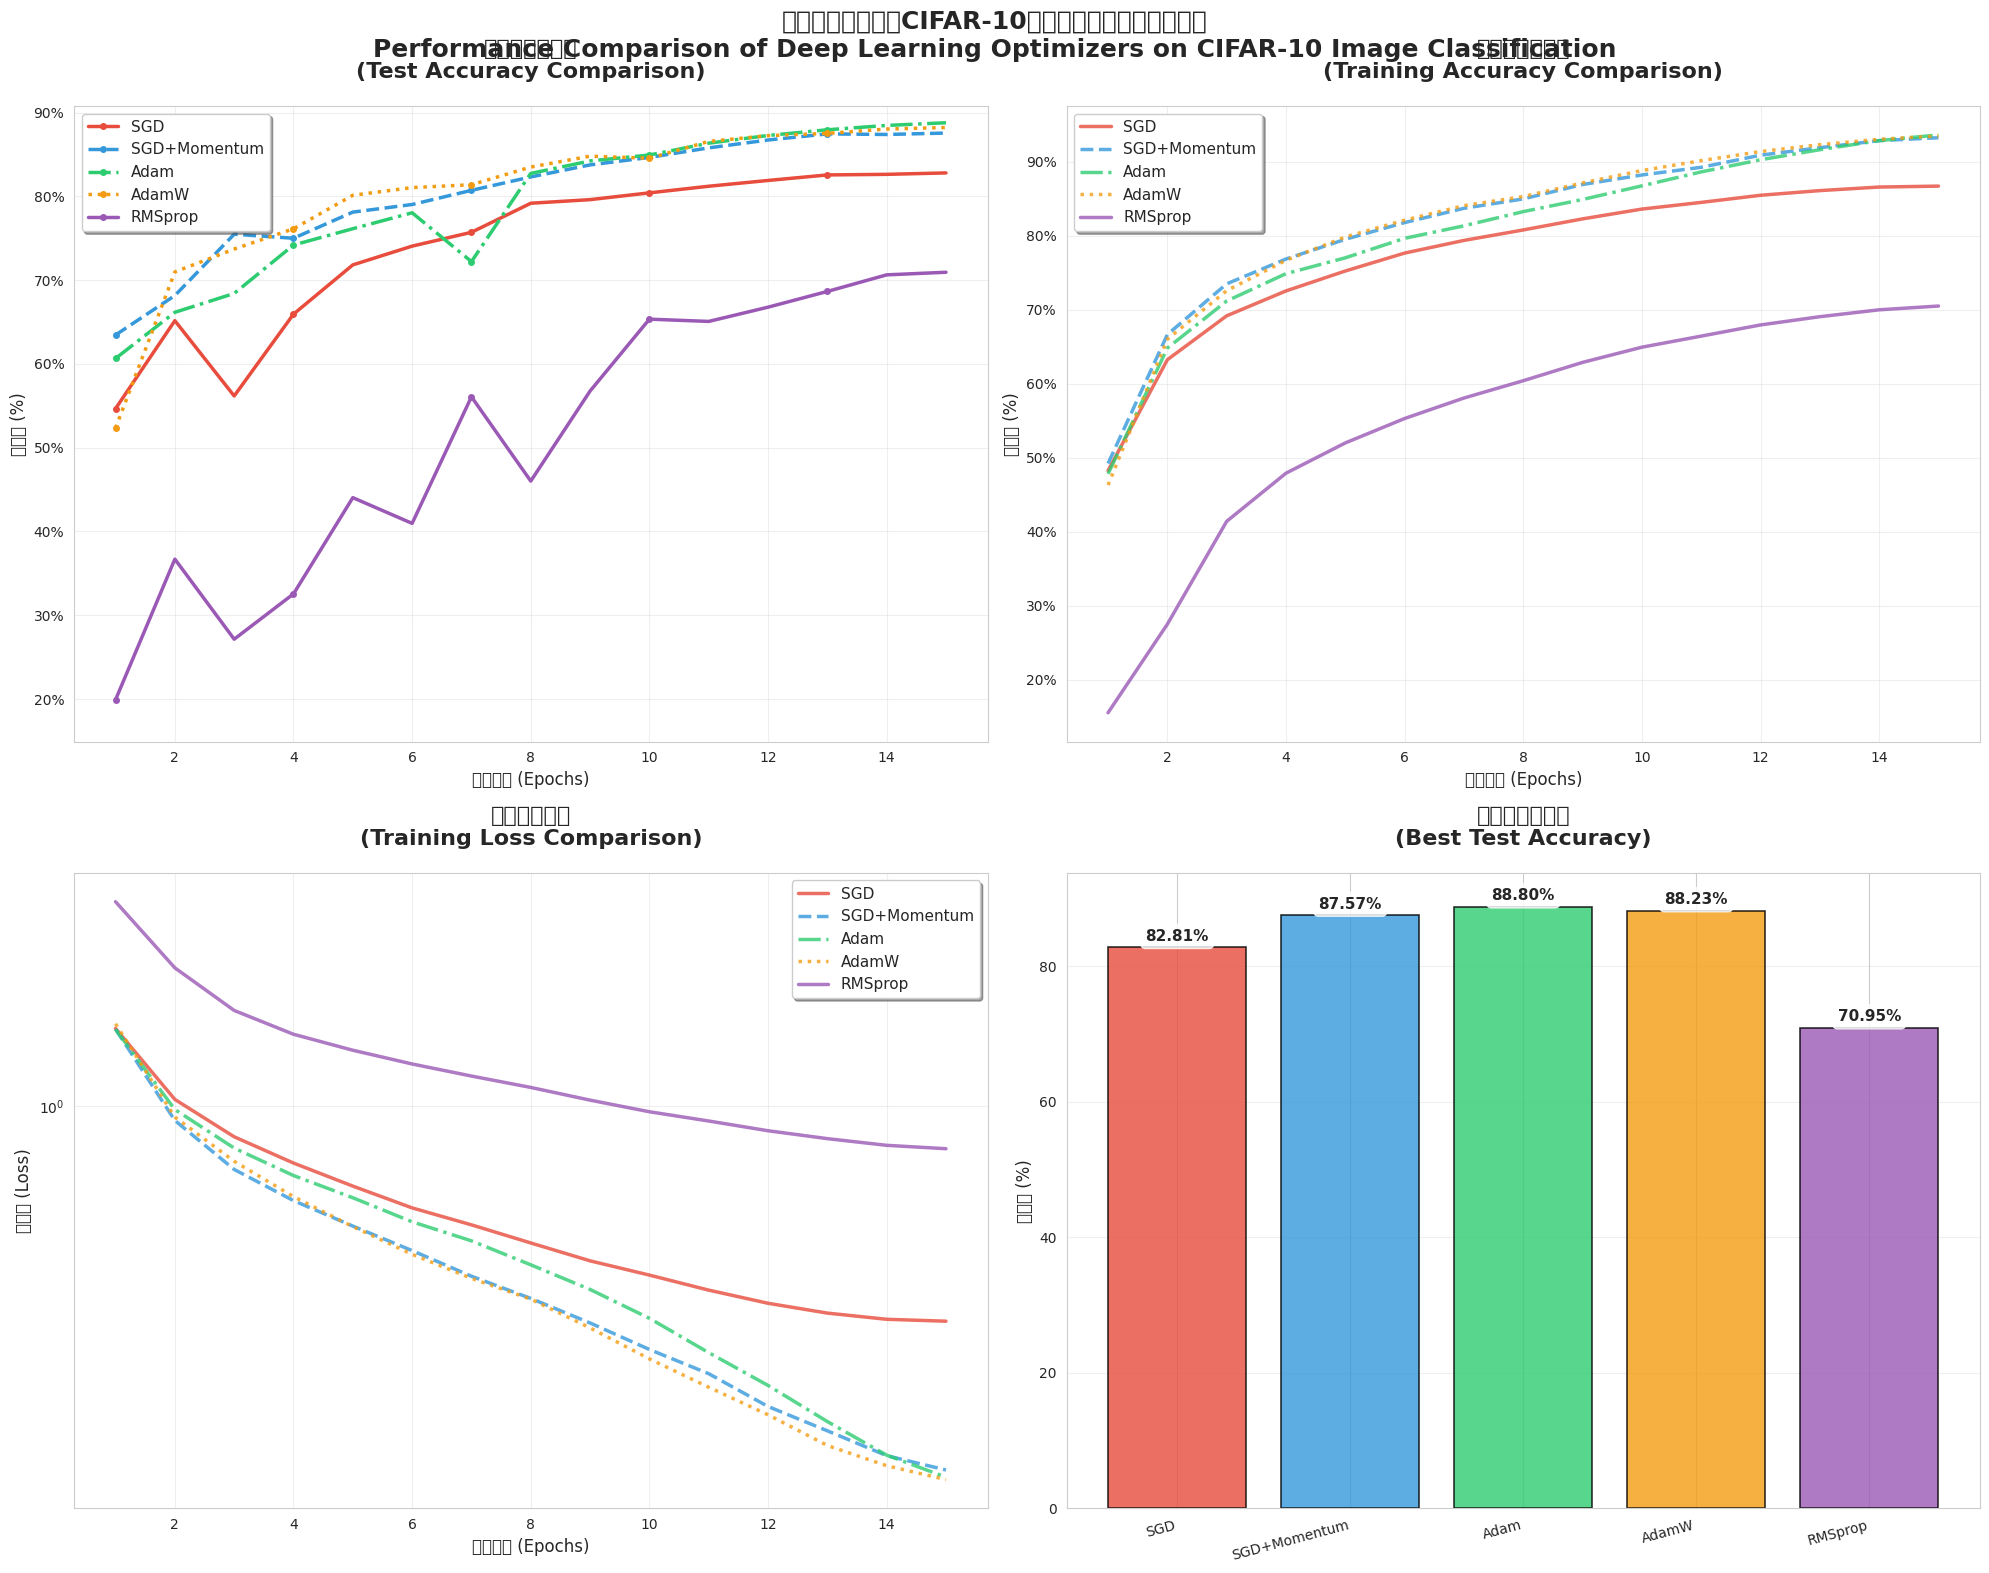


                    优化器性能对比表
               Optimizer Performance Comparison Table
优化器             | 最佳准确率        | 最终准确率        | 训练时间       | 相对性能
Optimizer       | Best Acc (%) | Final Acc (%) | Time (s)   | Relative
----------------------------------------------------------------------
SGD             |       82.81% |       82.81% |     326.8 | ★★★ (93.3%)
SGD+Momentum    |       87.57% |       87.57% |     322.9 | ★★★★★ (98.6%)
Adam            |       88.80% |       88.80% |     318.9 | ★★★★★ (100.0%)
AdamW           |       88.23% |       88.23% |     319.3 | ★★★★★ (99.4%)
RMSprop         |       70.95% |       70.95% |     317.2 | ★ (79.9%)

收敛速度分析 (Convergence Speed Analysis):
--------------------------------------------------
SGD            : 80% @ Epoch 10 | 未达到90%
SGD+Momentum   : 80% @ Epoch 7 | 未达到90%
Adam           : 80% @ Epoch 8 | 未达到90%
AdamW          : 80% @ Epoch 5 | 未达到90%
RMSprop        : 未达到80% | 未达到90%


In [18]:
# 美化版结果可视化
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import PercentFormatter

# 设置中文字体和美观的样式
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 使用支持中文的字体
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# 读取结果
optimizers = ['sgd', 'sgd_momentum', 'adam', 'adamw', 'rmsprop']
results = {}

for opt in optimizers:
    try:
        with open(f'{opt}_results.json', 'r') as f:
            results[opt] = json.load(f)
        print(f"成功读取 {opt} 的结果")
    except Exception as e:
        print(f"读取 {opt} 结果失败: {e}")

if not results:
    print("没有找到任何结果文件！")
else:
    # 创建美观的图表
    fig = plt.figure(figsize=(20, 16))

    # 优化器名称映射（用于显示）
    opt_names = {
        'sgd': 'SGD',
        'sgd_momentum': 'SGD+Momentum',
        'adam': 'Adam',
        'adamw': 'AdamW',
        'rmsprop': 'RMSprop'
    }

    # 颜色方案 - 使用更专业的颜色
    colors = {
        'sgd': '#E74C3C',  # 红色
        'sgd_momentum': '#3498DB',  # 蓝色
        'adam': '#2ECC71',  # 绿色
        'adamw': '#F39C12',  # 橙色
        'rmsprop': '#9B59B6'  # 紫色
    }

    # 线型方案
    line_styles = {
        'sgd': '-',
        'sgd_momentum': '--',
        'adam': '-.',
        'adamw': ':',
        'rmsprop': '-'
    }

    # 1. 测试准确率曲线 - 主要结果
    ax1 = plt.subplot(2, 2, 1)
    for opt, data in results.items():
        epochs = range(1, len(data['test_accuracies']) + 1)
        plt.plot(epochs, data['test_accuracies'],
                label=opt_names[opt],
                color=colors[opt],
                linestyle=line_styles[opt],
                linewidth=2.5,
                marker='o',
                markersize=4,
                markevery=3)

    plt.title('测试准确率对比\n(Test Accuracy Comparison)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('训练轮次 (Epochs)', fontsize=12)
    plt.ylabel('准确率 (%)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(PercentFormatter())
    # 设置y轴范围，让图表更紧凑
    all_acc = [acc for data in results.values() for acc in data['test_accuracies']]
    plt.ylim(max(0, min(all_acc) - 5), min(100, max(all_acc) + 2))

    # 2. 训练准确率曲线
    ax2 = plt.subplot(2, 2, 2)
    for opt, data in results.items():
        epochs = range(1, len(data['train_accuracies']) + 1)
        plt.plot(epochs, data['train_accuracies'],
                label=opt_names[opt],
                color=colors[opt],
                linestyle=line_styles[opt],
                linewidth=2.5,
                alpha=0.8)

    plt.title('训练准确率对比\n(Training Accuracy Comparison)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('训练轮次 (Epochs)', fontsize=12)
    plt.ylabel('准确率 (%)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(PercentFormatter())

    # 3. 训练损失曲线
    ax3 = plt.subplot(2, 2, 3)
    for opt, data in results.items():
        epochs = range(1, len(data['train_losses']) + 1)
        plt.plot(epochs, data['train_losses'],
                label=opt_names[opt],
                color=colors[opt],
                linestyle=line_styles[opt],
                linewidth=2.5,
                alpha=0.8)

    plt.title('训练损失对比\n(Training Loss Comparison)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('训练轮次 (Epochs)', fontsize=12)
    plt.ylabel('损失值 (Loss)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)
    # 使用对数坐标如果损失值变化范围很大
    if max([max(data['train_losses']) for data in results.values()]) > 10 * min([min(data['train_losses']) for data in results.values()]):
        plt.yscale('log')

    # 4. 最佳准确率柱状图 - 重点突出
    ax4 = plt.subplot(2, 2, 4)
    names = [opt_names[opt] for opt in results.keys()]
    best_accs = [results[opt]['best_accuracy'] for opt in results.keys()]
    colors_list = [colors[opt] for opt in results.keys()]

    bars = plt.bar(names, best_accs, color=colors_list, edgecolor='black', linewidth=1.2, alpha=0.8)

    # 美化柱状图
    plt.title('最佳测试准确率\n(Best Test Accuracy)', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('准确率 (%)', fontsize=12)
    plt.xticks(rotation=15, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # 在柱子上添加数值，美化显示
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{acc:.2f}%',
                ha='center', va='bottom',
                fontsize=11,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

    # 设置y轴范围，让柱状图看起来更舒服
    plt.ylim(0, max(best_accs) + 5)

    # 添加整体标题
    plt.suptitle('深度学习优化器在CIFAR-10图像分类任务上的性能对比\n'
                'Performance Comparison of Deep Learning Optimizers on CIFAR-10 Image Classification',
                fontsize=18, fontweight='bold', y=0.98)

    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)

    # 保存高质量图片
    plt.savefig('optimizer_comparison_beautiful.png', dpi=350, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('optimizer_comparison_beautiful.pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')

    plt.show()

    # 打印美化版的性能表格
    print("\n" + "="*70)
    print(" " * 20 + "优化器性能对比表")
    print(" " * 15 + "Optimizer Performance Comparison Table")
    print("="*70)
    print(f"{'优化器':<15} | {'最佳准确率':<12} | {'最终准确率':<12} | {'训练时间':<10} | {'相对性能'}")
    print(f"{'Optimizer':<15} | {'Best Acc (%)':<12} | {'Final Acc (%)':<12} | {'Time (s)':<10} | {'Relative'}")
    print("-" * 70)

    # 计算相对性能（以最佳准确率为基准）
    best_overall = max([data['best_accuracy'] for data in results.values()])

    for opt, data in results.items():
        best_acc = data['best_accuracy']
        final_acc = data['test_accuracies'][-1]
        time_taken = data['training_time']
        relative_perf = best_acc / best_overall * 100

        # 添加性能评级
        if relative_perf >= 98:
            rating = "★★★★★"
        elif relative_perf >= 95:
            rating = "★★★★"
        elif relative_perf >= 90:
            rating = "★★★"
        elif relative_perf >= 85:
            rating = "★★"
        else:
            rating = "★"

        print(f"{opt_names[opt]:<15} | {best_acc:11.2f}% | {final_acc:11.2f}% | {time_taken:9.1f} | {rating} ({relative_perf:.1f}%)")

    print("="*70)

    # 额外分析：收敛速度
    print("\n收敛速度分析 (Convergence Speed Analysis):")
    print("-" * 50)

    for opt, data in results.items():
        accuracies = data['test_accuracies']
        # 找到达到80%准确率的轮次
        reached_80 = None
        for i, acc in enumerate(accuracies):
            if acc >= 80:
                reached_80 = i + 1
                break
        # 找到达到90%准确率的轮次
        reached_90 = None
        for i, acc in enumerate(accuracies):
            if acc >= 90:
                reached_90 = i + 1
                break

        print(f"{opt_names[opt]:<15}: ", end="")
        if reached_80:
            print(f"80% @ Epoch {reached_80}", end=" | ")
        else:
            print("未达到80%", end=" | ")

        if reached_90:
            print(f"90% @ Epoch {reached_90}")
        else:
            print("未达到90%")


生成高级分析图表...


/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1798888295.py:125: UserWarning: Glyph 20339 (\N{CJK UNIFIED IDEOGRAPH-4F73}

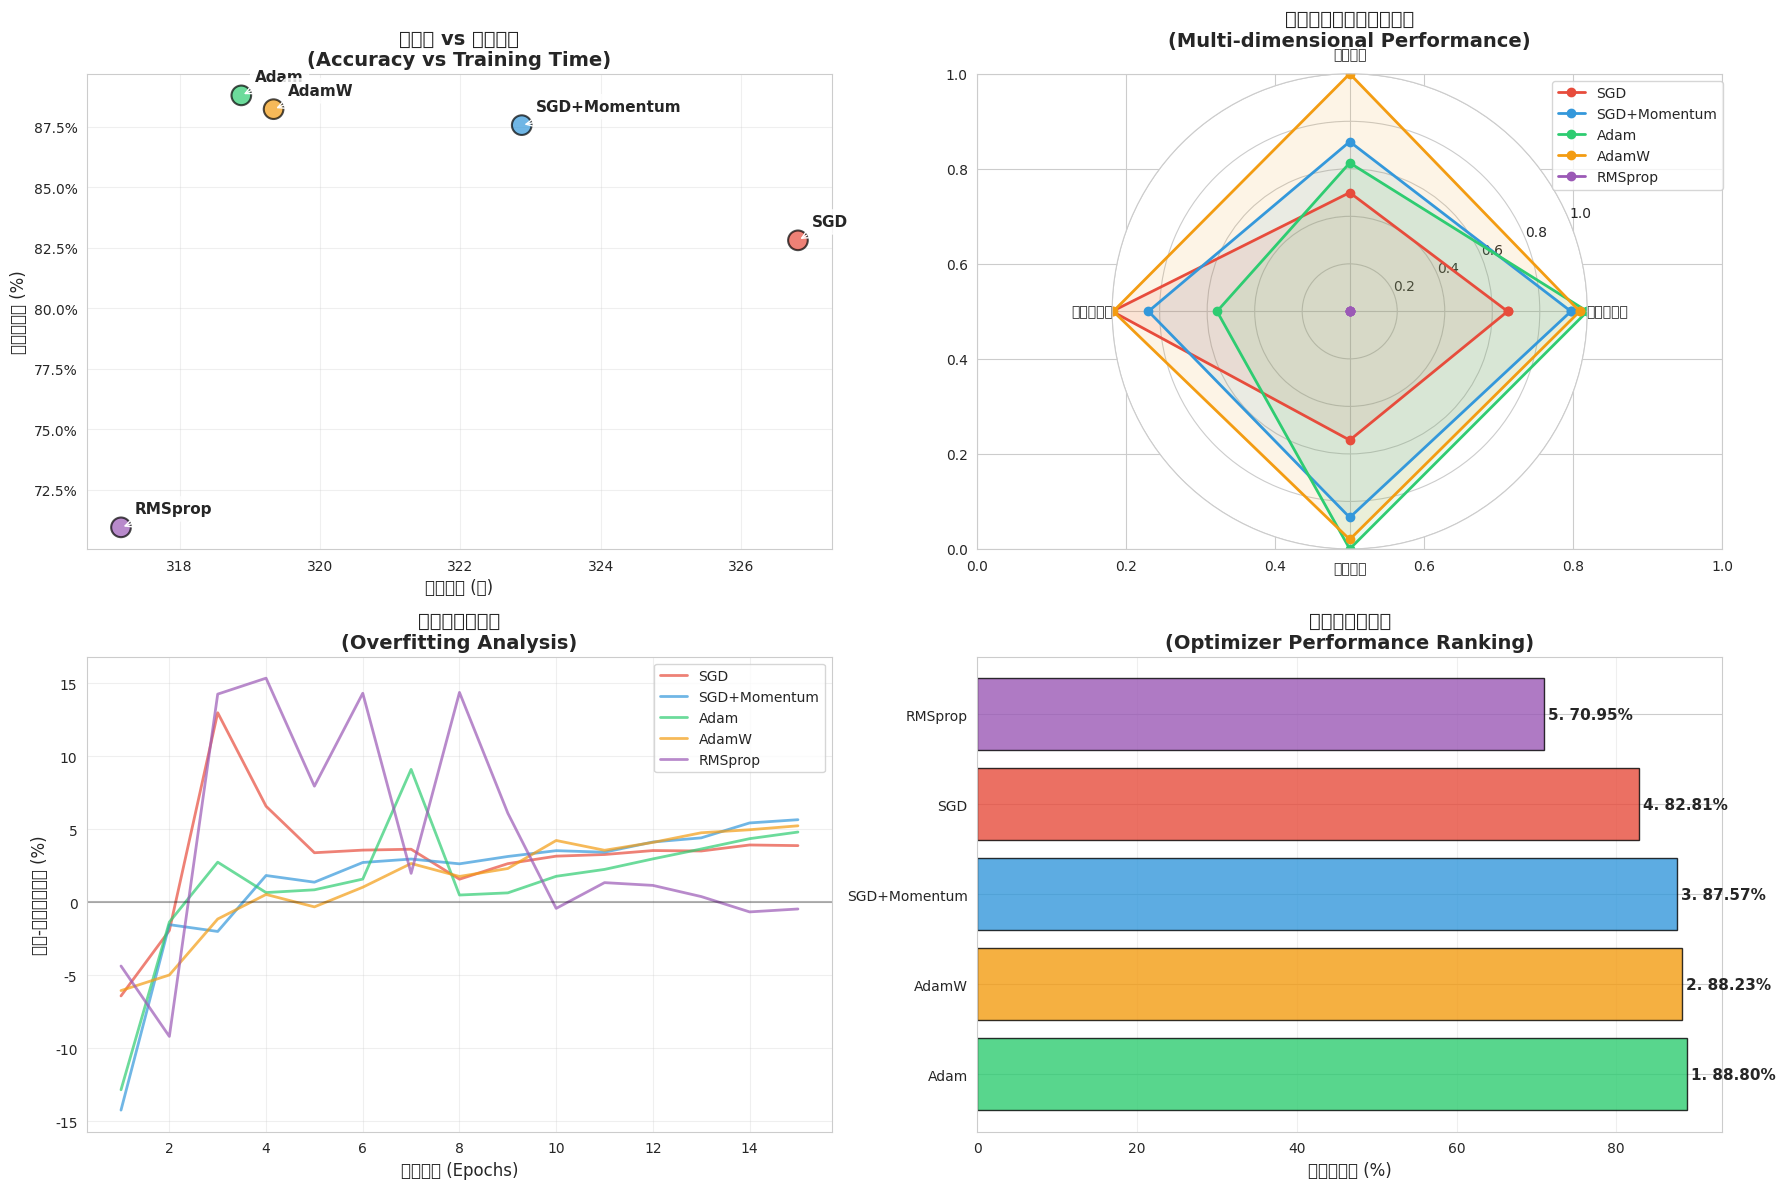

高级分析图表生成完成！


In [20]:
# 高级分析：创建更多专业图表
print("\n生成高级分析图表...")

# 创建第二个图表：性能综合对比
fig2, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# 1. 准确率-时间散点图（效率对比）
accuracies = [results[opt]['best_accuracy'] for opt in results.keys()]
times = [results[opt]['training_time'] for opt in results.keys()]
labels = [opt_names[opt] for opt in results.keys()]
colors_list = [colors[opt] for opt in results.keys()]

scatter = ax1.scatter(times, accuracies, c=colors_list, s=200, alpha=0.7, edgecolors='black', linewidth=1.5)

# 添加标签
for i, label in enumerate(labels):
    ax1.annotate(label, (times[i], accuracies[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"))

ax1.set_xlabel('训练时间 (秒)', fontsize=12)
ax1.set_ylabel('最佳准确率 (%)', fontsize=12)
ax1.set_title('准确率 vs 训练时间\n(Accuracy vs Training Time)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(PercentFormatter())

# 2. 相对性能雷达图
categories = ['最终准确率', '收敛速度', '训练稳定性', '计算效率']
N = len(categories)

# 计算各项指标（归一化到0-1）
final_acc_norm = [results[opt]['test_accuracies'][-1]/100 for opt in results.keys()]
# 收敛速度：以达到80%准确率的轮次倒数作为指标
convergence_speed = []
for opt in results.keys():
    accuracies = results[opt]['test_accuracies']
    for i, acc in enumerate(accuracies):
        if acc >= 80:
            convergence_speed.append(1/(i+1))  # 轮次越少，速度越快
            break
    else:
        convergence_speed.append(0)  # 未达到80%

# 训练稳定性：以最后5个epoch准确率的标准差倒数作为指标
stability = []
for opt in results.keys():
    last_5_acc = results[opt]['test_accuracies'][-5:]
    if len(last_5_acc) > 1:
        stability.append(1/np.std(last_5_acc))
    else:
        stability.append(1)

# 计算效率：以准确率/时间的比值作为指标
efficiency = [results[opt]['best_accuracy']/results[opt]['training_time'] for opt in results.keys()]

# 归一化所有指标到0-1范围
def normalize(values):
    min_val, max_val = min(values), max(values)
    if max_val == min_val:
        return [0.5] * len(values)
    return [(v - min_val) / (max_val - min_val) for v in values]

final_acc_norm = normalize(final_acc_norm)
convergence_speed = normalize(convergence_speed)
stability = normalize(stability)
efficiency = normalize(efficiency)

# 绘制雷达图
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # 闭合图形

ax2 = plt.subplot(2, 2, 2, polar=True)
for i, opt in enumerate(results.keys()):
    values = [final_acc_norm[i], convergence_speed[i], stability[i], efficiency[i]]
    values += values[:1]  # 闭合图形
    ax2.plot(angles, values, 'o-', linewidth=2, label=opt_names[opt], color=colors[opt])
    ax2.fill(angles, values, alpha=0.1, color=colors[opt])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_ylim(0, 1)
ax2.set_title('优化器多维度性能雷达图\n(Multi-dimensional Performance)', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# 3. 训练过程动态图（可选）
ax3 = plt.subplot(2, 2, 3)
for opt, data in results.items():
    # 绘制训练和测试准确率的差异
    epochs = range(1, len(data['train_accuracies']) + 1)
    gap = [train - test for train, test in zip(data['train_accuracies'], data['test_accuracies'])]
    ax3.plot(epochs, gap, label=opt_names[opt], color=colors[opt], linewidth=2, alpha=0.7)

ax3.set_xlabel('训练轮次 (Epochs)', fontsize=12)
ax3.set_ylabel('训练-测试准确率差 (%)', fontsize=12)
ax3.set_title('过拟合程度分析\n(Overfitting Analysis)', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 4. 性能排名柱状图
ax4 = plt.subplot(2, 2, 4)
# 按最佳准确率排序
sorted_opts = sorted(results.keys(), key=lambda x: results[x]['best_accuracy'], reverse=True)
sorted_names = [opt_names[opt] for opt in sorted_opts]
sorted_accs = [results[opt]['best_accuracy'] for opt in sorted_opts]
sorted_colors = [colors[opt] for opt in sorted_opts]

bars = ax4.barh(sorted_names, sorted_accs, color=sorted_colors, alpha=0.8, edgecolor='black')

# 美化横向柱状图
ax4.set_xlabel('最佳准确率 (%)', fontsize=12)
ax4.set_title('优化器性能排名\n(Optimizer Performance Ranking)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# 在柱子上添加数值和排名
for i, (bar, acc) in enumerate(zip(bars, sorted_accs)):
    width = bar.get_width()
    ax4.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{i+1}. {acc:.2f}%',
            va='center', ha='left',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('advanced_analysis.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print("高级分析图表生成完成！")

Successfully loaded sgd results
Successfully loaded sgd_momentum results
Successfully loaded adam results
Successfully loaded adamw results
Successfully loaded rmsprop results
Using log scale for loss due to large value range


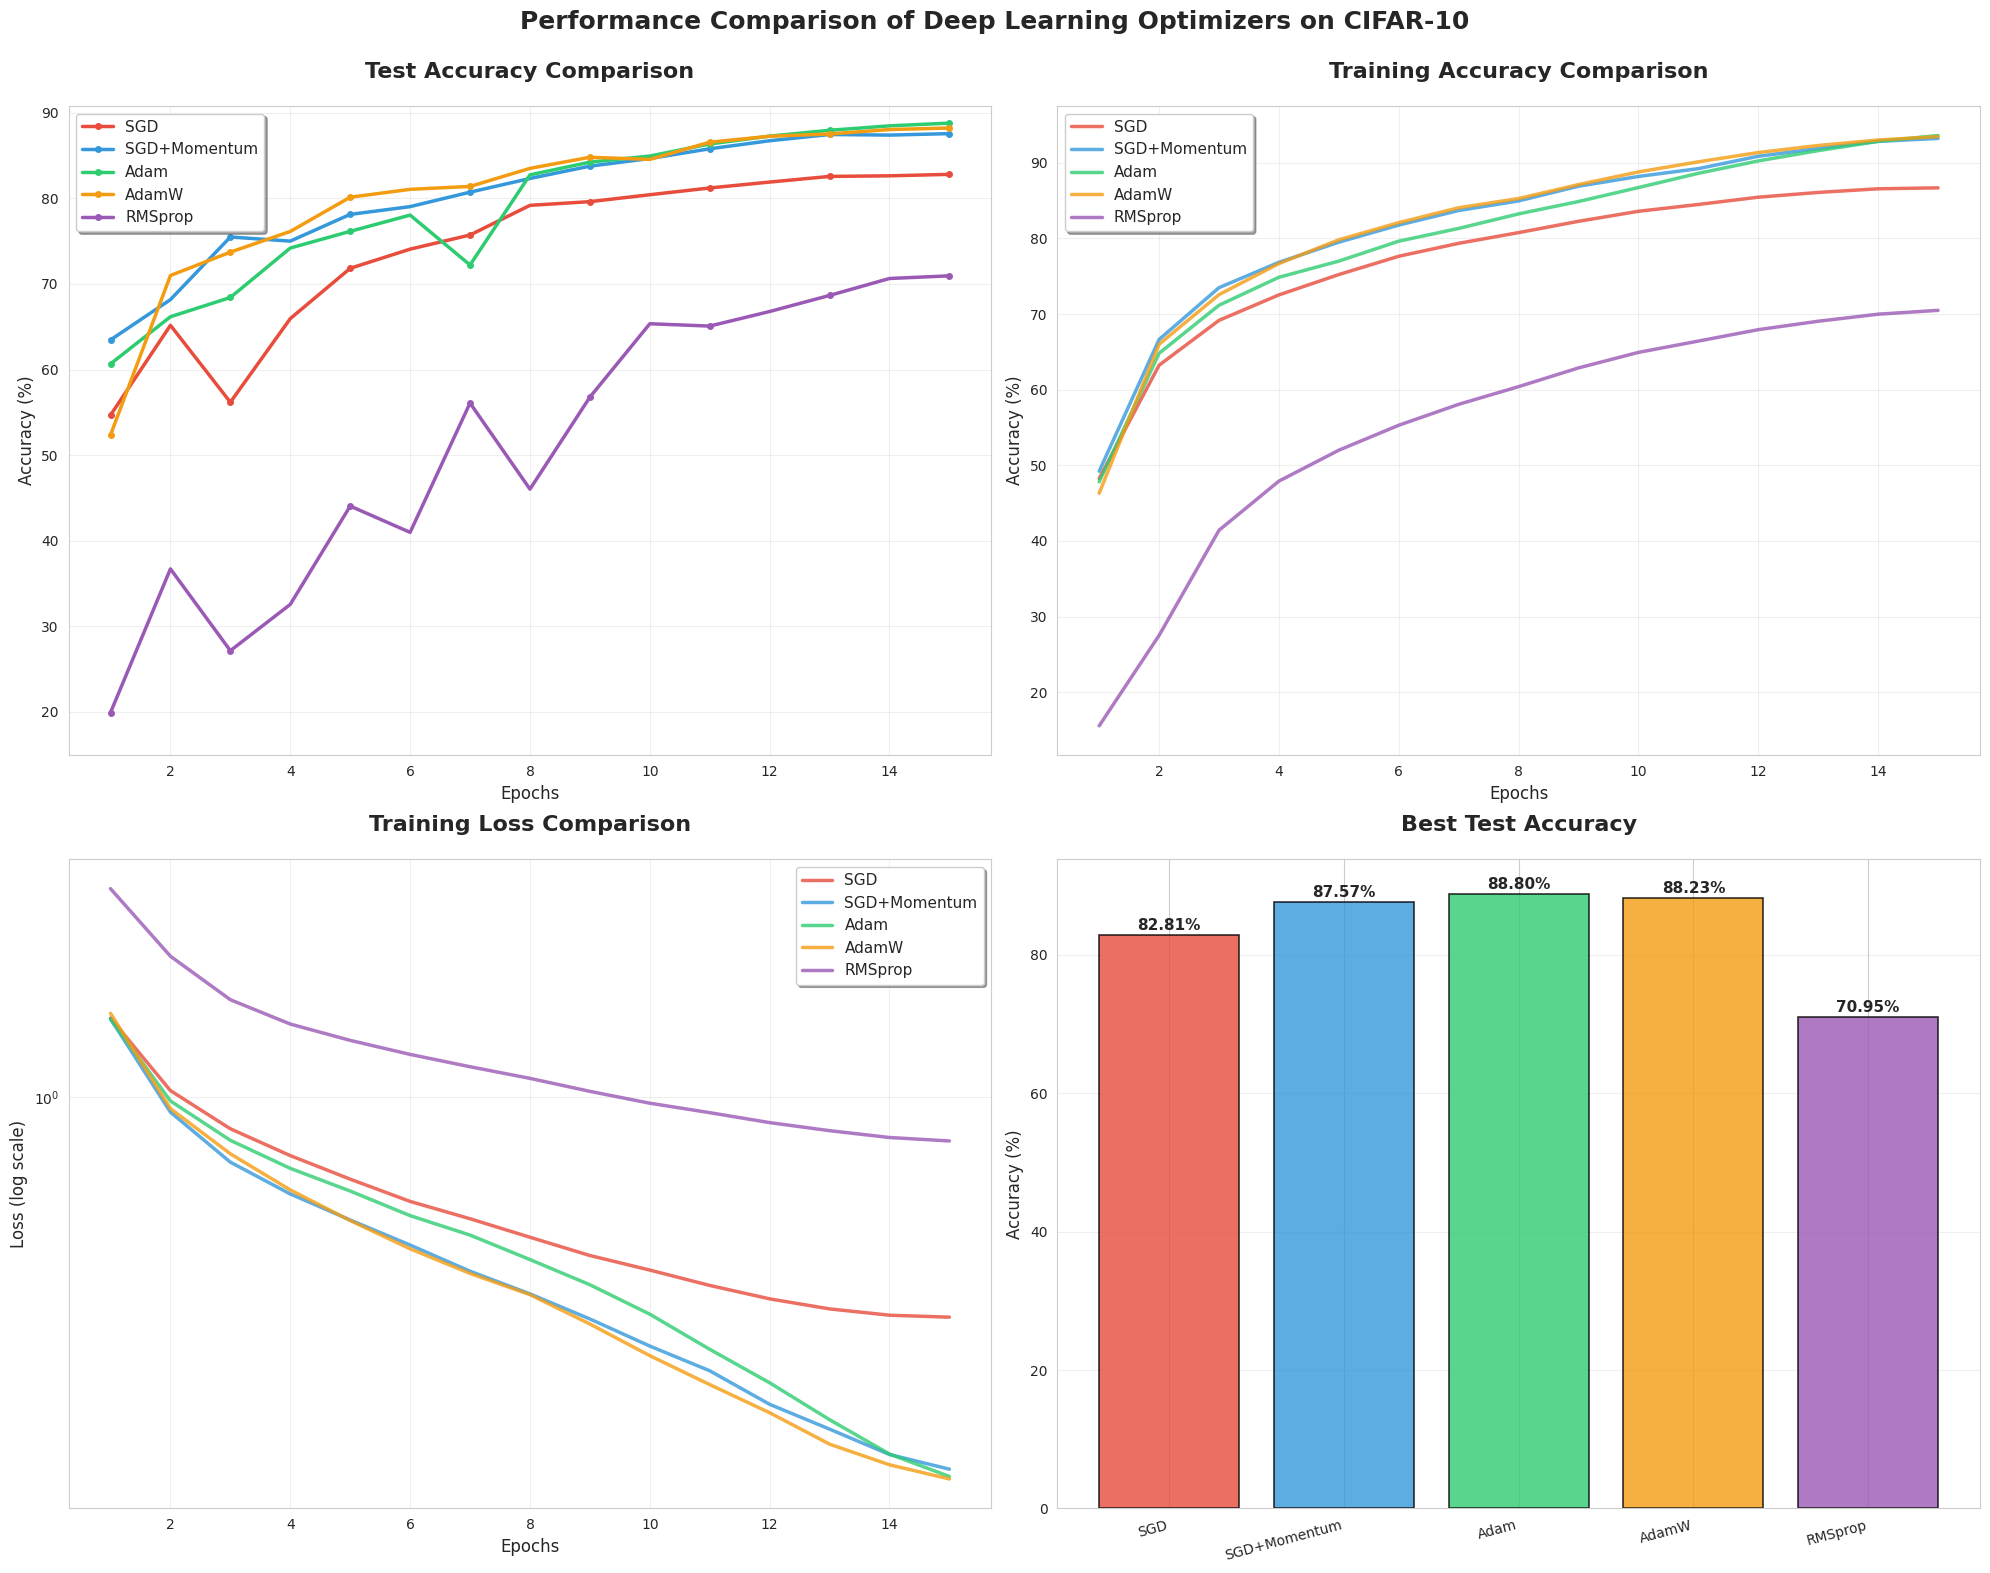


Optimizer Performance Comparison Table
Optimizer       | Best Acc   | Final Acc  | Time (s)   | Performance
--------------------------------------------------------------------------------
SGD             |    82.81% |    82.81% |    326.8 | ★★★ (93.3%)
SGD+Momentum    |    87.57% |    87.57% |    322.9 | ★★★★★ (98.6%)
Adam            |    88.80% |    88.80% |    318.9 | ★★★★★ (100.0%)
AdamW           |    88.23% |    88.23% |    319.3 | ★★★★★ (99.4%)
RMSprop         |    70.95% |    70.95% |    317.2 | ★ (79.9%)

Convergence Speed Analysis:
--------------------------------------------------
SGD            : 70% @ Epoch 5 | 80% @ Epoch 10
SGD+Momentum   : 70% @ Epoch 3 | 80% @ Epoch 7
Adam           : 70% @ Epoch 4 | 80% @ Epoch 8
AdamW          : 70% @ Epoch 2 | 80% @ Epoch 5
RMSprop        : 70% @ Epoch 14 | Not reached 80%


In [21]:
# 修复版结果可视化 - 解决loss坐标和中文显示问题
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import PercentFormatter

# 设置英文字体，避免中文显示问题
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# 读取结果
optimizers = ['sgd', 'sgd_momentum', 'adam', 'adamw', 'rmsprop']
results = {}

for opt in optimizers:
    try:
        with open(f'{opt}_results.json', 'r') as f:
            results[opt] = json.load(f)
        print(f"Successfully loaded {opt} results")
    except Exception as e:
        print(f"Failed to load {opt} results: {e}")

if not results:
    print("No result files found!")
else:
    # 创建图表 - 全部使用英文
    fig = plt.figure(figsize=(20, 16))

    # 优化器名称映射
    opt_names = {
        'sgd': 'SGD',
        'sgd_momentum': 'SGD+Momentum',
        'adam': 'Adam',
        'adamw': 'AdamW',
        'rmsprop': 'RMSprop'
    }

    # 颜色方案
    colors = {
        'sgd': '#E74C3C',  # 红色
        'sgd_momentum': '#3498DB',  # 蓝色
        'adam': '#2ECC71',  # 绿色
        'adamw': '#F39C12',  # 橙色
        'rmsprop': '#9B59B6'  # 紫色
    }

    # 1. 测试准确率曲线
    ax1 = plt.subplot(2, 2, 1)
    for opt, data in results.items():
        epochs = range(1, len(data['test_accuracies']) + 1)
        plt.plot(epochs, data['test_accuracies'],
                label=opt_names[opt],
                color=colors[opt],
                linewidth=2.5,
                marker='o',
                markersize=4,
                markevery=2)

    plt.title('Test Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)

    # 设置合理的y轴范围
    all_test_acc = [acc for data in results.values() for acc in data['test_accuracies']]
    y_min = max(0, min(all_test_acc) - 5)
    y_max = min(100, max(all_test_acc) + 2)
    plt.ylim(y_min, y_max)

    # 2. 训练准确率曲线
    ax2 = plt.subplot(2, 2, 2)
    for opt, data in results.items():
        epochs = range(1, len(data['train_accuracies']) + 1)
        plt.plot(epochs, data['train_accuracies'],
                label=opt_names[opt],
                color=colors[opt],
                linewidth=2.5,
                alpha=0.8)

    plt.title('Training Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)

    # 3. 训练损失曲线 - 修复纵坐标问题
    ax3 = plt.subplot(2, 2, 3)

    # 检查loss值的范围，决定是否使用对数坐标
    all_losses = [loss for data in results.values() for loss in data['train_losses']]
    max_loss = max(all_losses)
    min_loss = min(all_losses)

    # 如果loss值范围很大（比如最大值是最小值的10倍以上），使用对数坐标
    use_log_scale = max_loss > 10 * min_loss and min_loss > 0

    for opt, data in results.items():
        epochs = range(1, len(data['train_losses']) + 1)
        plt.plot(epochs, data['train_losses'],
                label=opt_names[opt],
                color=colors[opt],
                linewidth=2.5,
                alpha=0.8)

    plt.title('Training Loss Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)

    if use_log_scale:
        plt.yscale('log')
        plt.ylabel('Loss (log scale)')
        print("Using log scale for loss due to large value range")
    else:
        # 设置合适的线性坐标范围
        loss_margin = (max_loss - min_loss) * 0.1
        plt.ylim(max(0, min_loss - loss_margin), max_loss + loss_margin)

    # 4. 最佳准确率柱状图
    ax4 = plt.subplot(2, 2, 4)
    names = [opt_names[opt] for opt in results.keys()]
    best_accs = [results[opt]['best_accuracy'] for opt in results.keys()]
    colors_list = [colors[opt] for opt in results.keys()]

    bars = plt.bar(names, best_accs, color=colors_list, edgecolor='black', linewidth=1.2, alpha=0.8)

    plt.title('Best Test Accuracy', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xticks(rotation=15, ha='right')
    plt.grid(True, alpha=0.3, axis='y')

    # 在柱子上添加数值
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.3,
                f'{acc:.2f}%',
                ha='center', va='bottom',
                fontsize=11,
                fontweight='bold')

    # 设置y轴范围
    plt.ylim(0, max(best_accs) + 5)

    # 添加整体标题
    plt.suptitle('Performance Comparison of Deep Learning Optimizers on CIFAR-10',
                fontsize=18, fontweight='bold', y=0.98)

    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)

    # 保存图片
    plt.savefig('optimizer_comparison_fixed.png', dpi=350, bbox_inches='tight',
                facecolor='white', edgecolor='none')

    plt.show()

    # 打印性能表格
    print("\n" + "="*80)
    print("Optimizer Performance Comparison Table")
    print("="*80)
    print(f"{'Optimizer':<15} | {'Best Acc':<10} | {'Final Acc':<10} | {'Time (s)':<10} | {'Performance'}")
    print("-" * 80)

    # 计算相对性能
    best_overall = max([data['best_accuracy'] for data in results.values()])

    for opt, data in results.items():
        best_acc = data['best_accuracy']
        final_acc = data['test_accuracies'][-1]
        time_taken = data['training_time']
        relative_perf = best_acc / best_overall * 100

        # 性能评级
        if relative_perf >= 98:
            rating = "★★★★★"
        elif relative_perf >= 95:
            rating = "★★★★"
        elif relative_perf >= 90:
            rating = "★★★"
        elif relative_perf >= 85:
            rating = "★★"
        else:
            rating = "★"

        print(f"{opt_names[opt]:<15} | {best_acc:8.2f}% | {final_acc:8.2f}% | {time_taken:8.1f} | {rating} ({relative_perf:.1f}%)")

    print("="*80)

    # 收敛速度分析
    print("\nConvergence Speed Analysis:")
    print("-" * 50)

    for opt, data in results.items():
        accuracies = data['test_accuracies']
        # 找到达到70%准确率的轮次
        reached_70 = None
        for i, acc in enumerate(accuracies):
            if acc >= 70:
                reached_70 = i + 1
                break
        # 找到达到80%准确率的轮次
        reached_80 = None
        for i, acc in enumerate(accuracies):
            if acc >= 80:
                reached_80 = i + 1
                break

        print(f"{opt_names[opt]:<15}: ", end="")
        if reached_70:
            print(f"70% @ Epoch {reached_70}", end=" | ")
        else:
            print("Not reached 70%", end=" | ")

        if reached_80:
            print(f"80% @ Epoch {reached_80}")
        else:
            print("Not reached 80%")


Generating Summary Charts...


/tmp/ipython-input-3732449300.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(names, rotation=15)


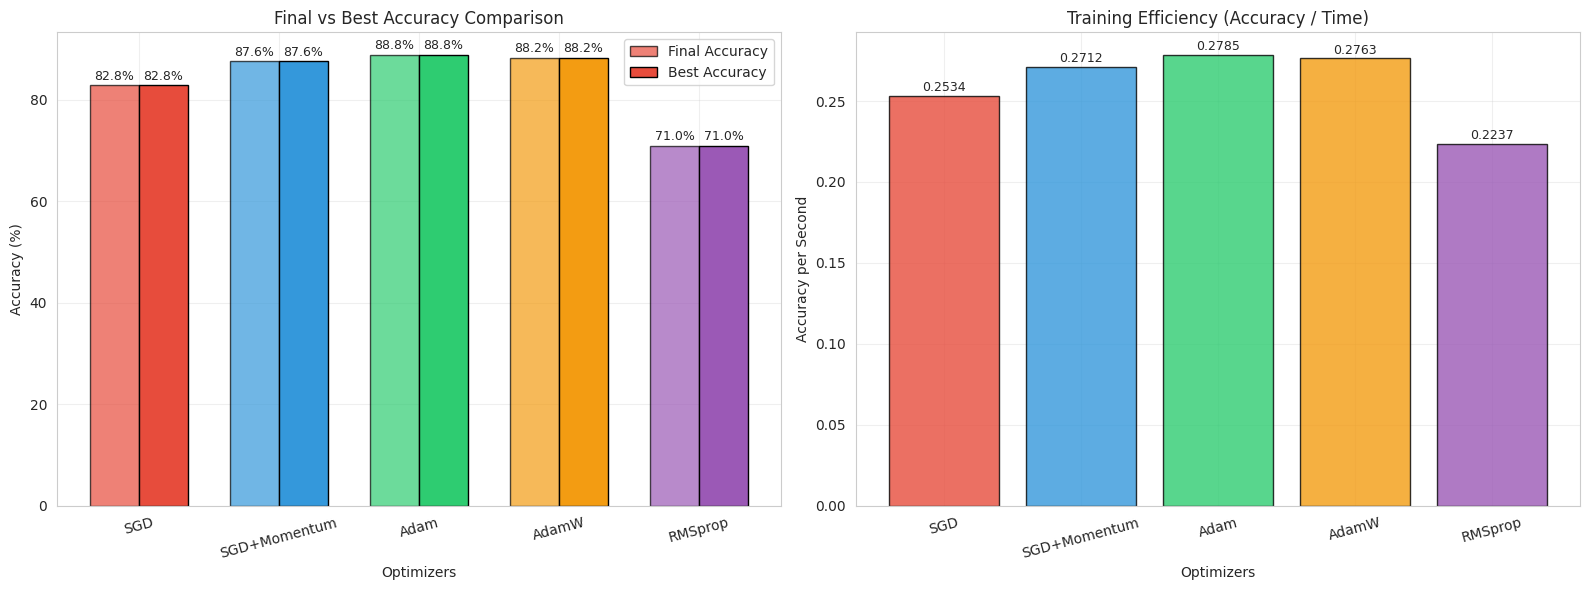

Summary charts generated successfully!


In [23]:
# 创建总结性图表
print("\nGenerating Summary Charts...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 最终性能对比
names = [opt_names[opt] for opt in results.keys()]
final_accs = [results[opt]['test_accuracies'][-1] for opt in results.keys()]
best_accs = [results[opt]['best_accuracy'] for opt in results.keys()]
colors_list = [colors[opt] for opt in results.keys()]

x = np.arange(len(names))
width = 0.35

bars1 = ax1.bar(x - width/2, final_accs, width, label='Final Accuracy',
                color=colors_list, alpha=0.7, edgecolor='black')
bars2 = ax1.bar(x + width/2, best_accs, width, label='Best Accuracy',
                color=colors_list, alpha=1.0, edgecolor='black')

ax1.set_xlabel('Optimizers')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Final vs Best Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 在柱子上添加数值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. 效率对比（准确率/时间）
efficiency = [results[opt]['best_accuracy'] / results[opt]['training_time'] for opt in results.keys()]

bars = ax2.bar(names, efficiency, color=colors_list, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Optimizers')
ax2.set_ylabel('Accuracy per Second')
ax2.set_title('Training Efficiency (Accuracy / Time)')
ax2.set_xticklabels(names, rotation=15)
ax2.grid(True, alpha=0.3)

# 在柱子上添加数值
for bar, eff in zip(bars, efficiency):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.001,
            f'{eff:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('summary_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary charts generated successfully!")


Generating Summary Charts...


/tmp/ipython-input-3732449300.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(names, rotation=15)


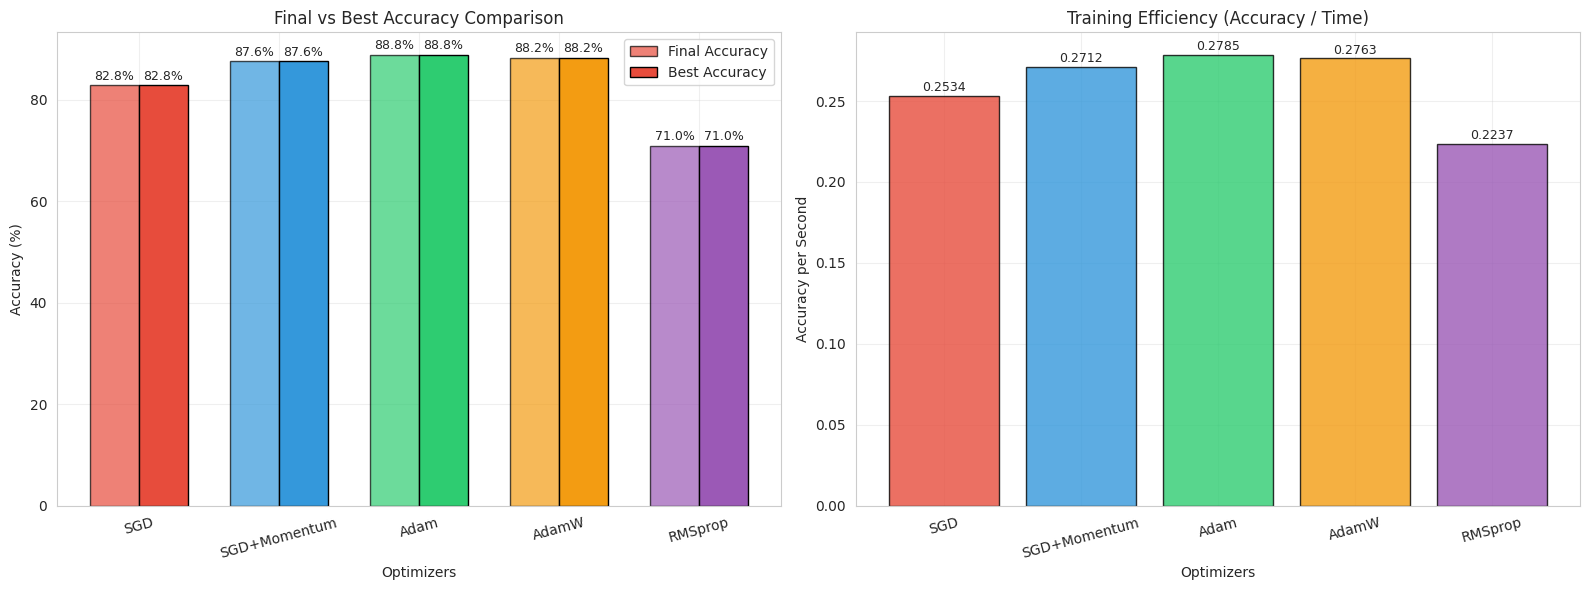

Summary charts generated successfully!


In [24]:
# 创建总结性图表
print("\nGenerating Summary Charts...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 最终性能对比
names = [opt_names[opt] for opt in results.keys()]
final_accs = [results[opt]['test_accuracies'][-1] for opt in results.keys()]
best_accs = [results[opt]['best_accuracy'] for opt in results.keys()]
colors_list = [colors[opt] for opt in results.keys()]

x = np.arange(len(names))
width = 0.35

bars1 = ax1.bar(x - width/2, final_accs, width, label='Final Accuracy',
                color=colors_list, alpha=0.7, edgecolor='black')
bars2 = ax1.bar(x + width/2, best_accs, width, label='Best Accuracy',
                color=colors_list, alpha=1.0, edgecolor='black')

ax1.set_xlabel('Optimizers')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Final vs Best Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 在柱子上添加数值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. 效率对比（准确率/时间）
efficiency = [results[opt]['best_accuracy'] / results[opt]['training_time'] for opt in results.keys()]

bars = ax2.bar(names, efficiency, color=colors_list, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Optimizers')
ax2.set_ylabel('Accuracy per Second')
ax2.set_title('Training Efficiency (Accuracy / Time)')
ax2.set_xticklabels(names, rotation=15)
ax2.grid(True, alpha=0.3)

# 在柱子上添加数值
for bar, eff in zip(bars, efficiency):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.001,
            f'{eff:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('summary_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Summary charts generated successfully!")

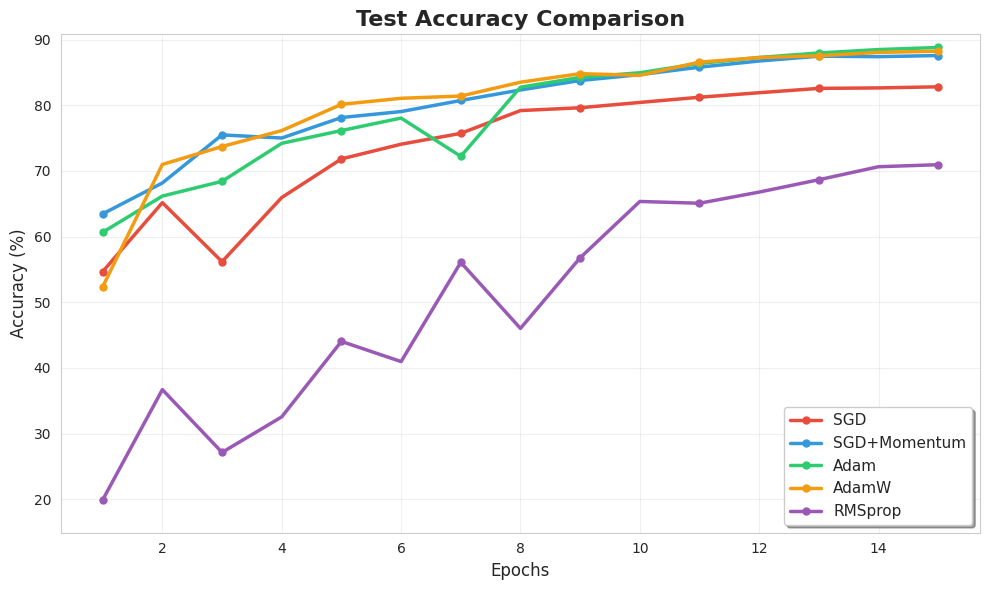

✅ Saved: test_accuracy_comparison.png


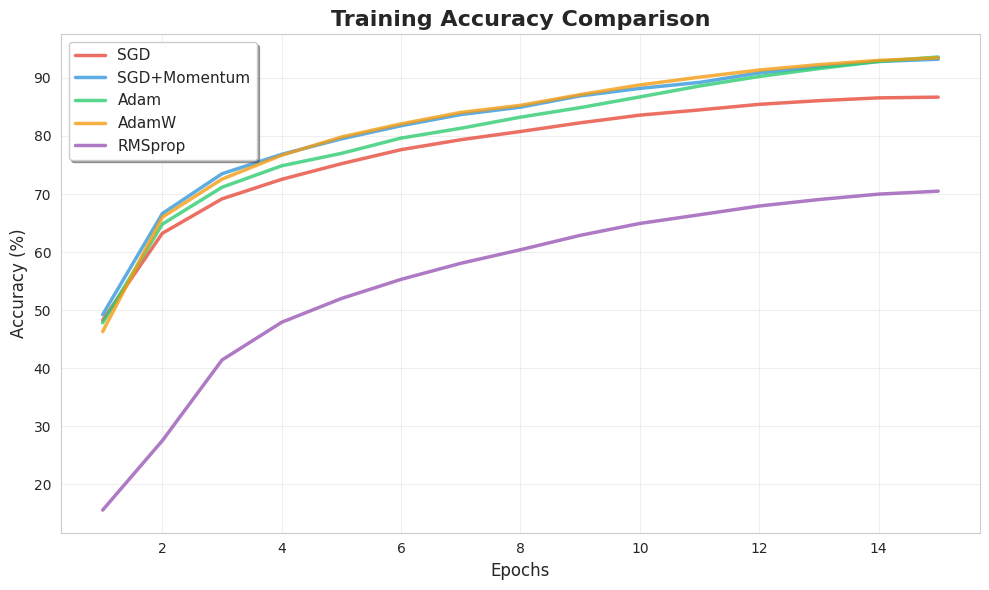

✅ Saved: training_accuracy_comparison.png
Using log scale for loss visualization


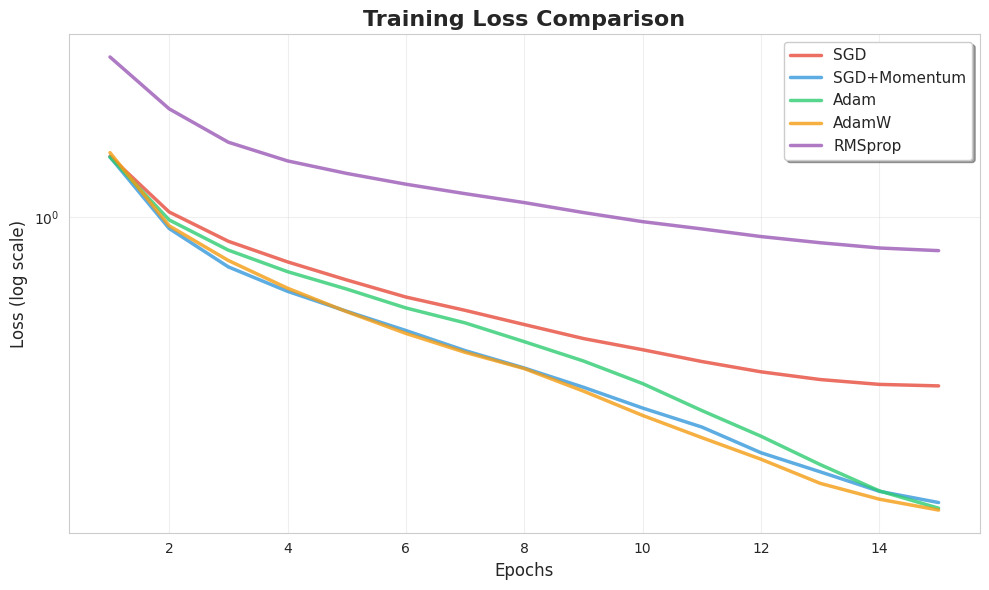

✅ Saved: training_loss_comparison.png


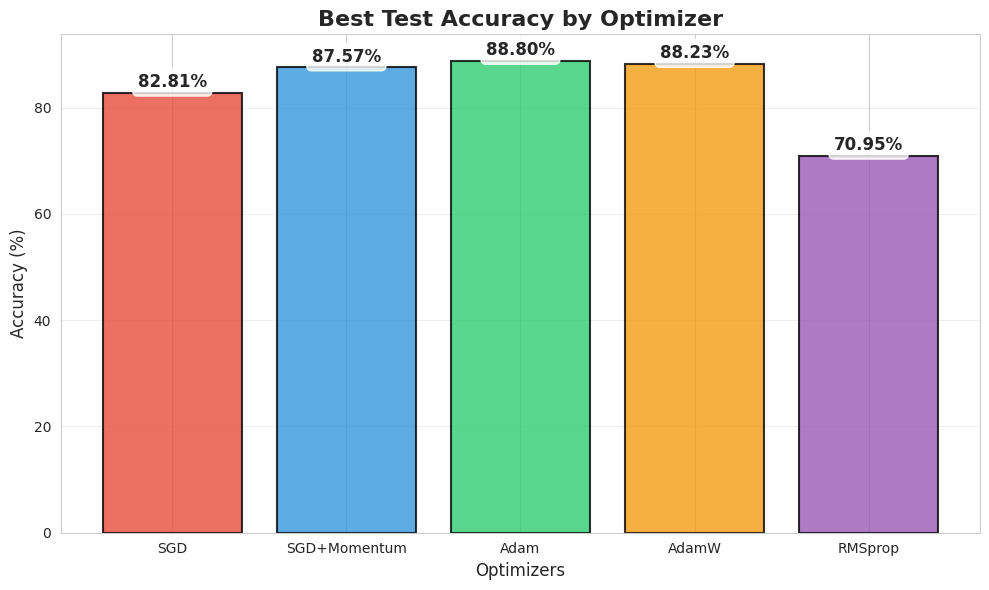

✅ Saved: best_accuracy_comparison.png


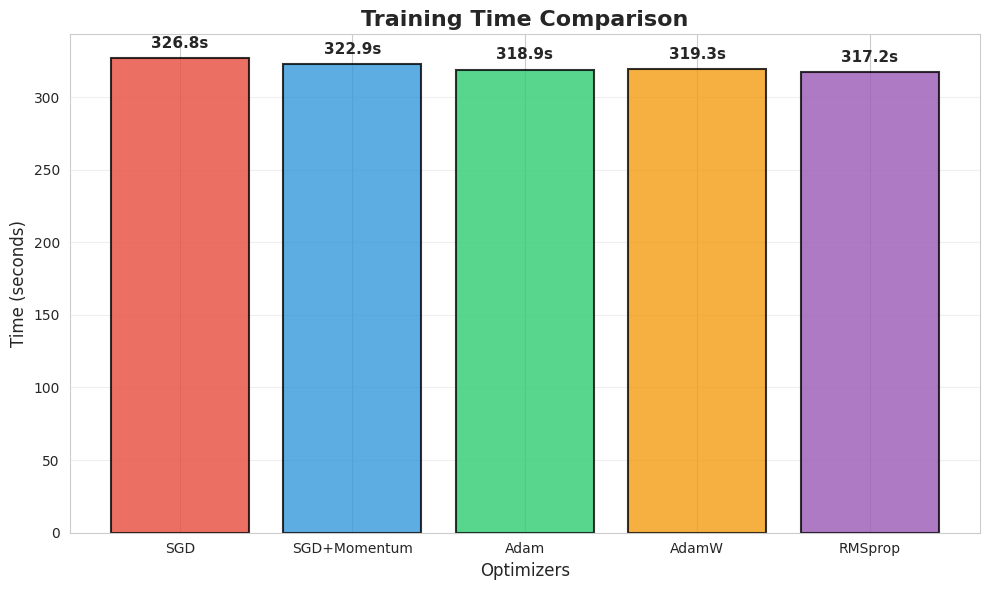

✅ Saved: training_time_comparison.png


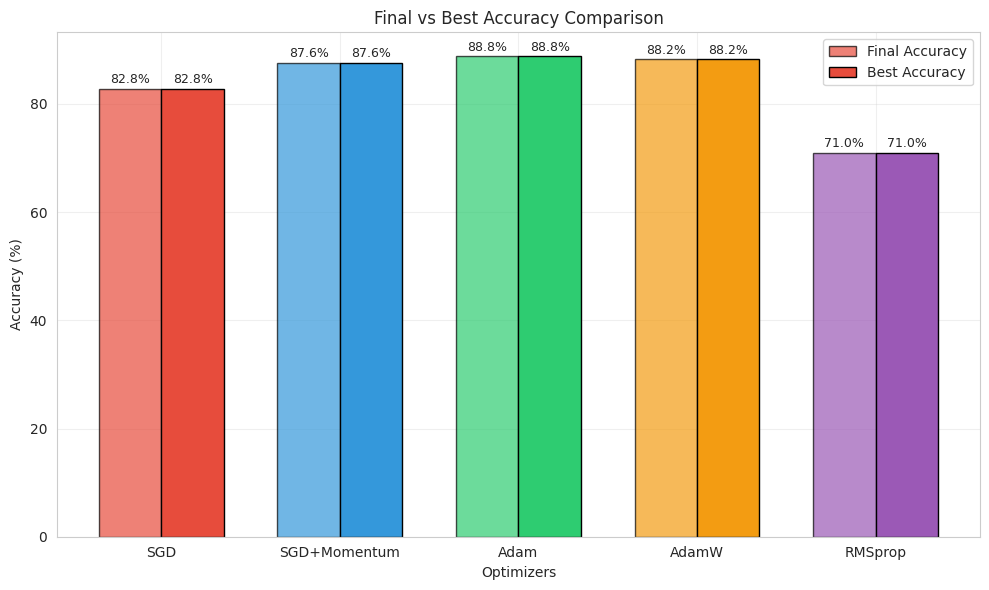

✅ Saved: final_vs_best_accuracy.png


In [27]:
# 分别生成每个小图并单独下载
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置样式
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 读取结果
optimizers = ['sgd', 'sgd_momentum', 'adam', 'adamw', 'rmsprop']
results = {}

for opt in optimizers:
    try:
        with open(f'{opt}_results.json', 'r') as f:
            results[opt] = json.load(f)
    except Exception as e:
        print(f"Failed to load {opt} results: {e}")

if not results:
    print("No result files found!")
else:
    # 优化器名称映射
    opt_names = {
        'sgd': 'SGD',
        'sgd_momentum': 'SGD+Momentum',
        'adam': 'Adam',
        'adamw': 'AdamW',
        'rmsprop': 'RMSprop'
    }

    # 颜色方案
    colors = {
        'sgd': '#E74C3C',
        'sgd_momentum': '#3498DB',
        'adam': '#2ECC71',
        'adamw': '#F39C12',
        'rmsprop': '#9B59B6'
    }

    # 1. 测试准确率曲线 - 单独图表
    plt.figure(figsize=(10, 6))
    for opt, data in results.items():
        epochs = range(1, len(data['test_accuracies']) + 1)
        plt.plot(epochs, data['test_accuracies'],
                label=opt_names[opt],
                color=colors[opt],
                linewidth=2.5,
                marker='o',
                markersize=5,
                markevery=2)

    plt.title('Test Accuracy Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)

    # 设置合理的y轴范围
    all_test_acc = [acc for data in results.values() for acc in data['test_accuracies']]
    y_min = max(0, min(all_test_acc) - 5)
    y_max = min(100, max(all_test_acc) + 2)
    plt.ylim(y_min, y_max)

    plt.tight_layout()
    plt.savefig('test_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig('test_accuracy_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Saved: test_accuracy_comparison.png")

    # 2. 训练准确率曲线 - 单独图表
    plt.figure(figsize=(10, 6))
    for opt, data in results.items():
        epochs = range(1, len(data['train_accuracies']) + 1)
        plt.plot(epochs, data['train_accuracies'],
                label=opt_names[opt],
                color=colors[opt],
                linewidth=2.5,
                alpha=0.8)

    plt.title('Training Accuracy Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig('training_accuracy_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Saved: training_accuracy_comparison.png")

    # 3. 训练损失曲线 - 单独图表
    plt.figure(figsize=(10, 6))

    # 检查是否使用对数坐标
    all_losses = [loss for data in results.values() for loss in data['train_losses']]
    max_loss = max(all_losses)
    min_loss = min(all_losses)
    use_log_scale = max_loss > 10 * min_loss and min_loss > 0

    for opt, data in results.items():
        epochs = range(1, len(data['train_losses']) + 1)
        plt.plot(epochs, data['train_losses'],
                label=opt_names[opt],
                color=colors[opt],
                linewidth=2.5,
                alpha=0.8)

    plt.title('Training Loss Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)

    if use_log_scale:
        plt.yscale('log')
        plt.ylabel('Loss (log scale)', fontsize=12)
        print("Using log scale for loss visualization")
    else:
        plt.ylabel('Loss', fontsize=12)
        # 设置合适的线性坐标范围
        loss_margin = (max_loss - min_loss) * 0.1
        plt.ylim(max(0, min_loss - loss_margin), max_loss + loss_margin)

    plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_loss_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig('training_loss_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Saved: training_loss_comparison.png")

    # 4. 最佳准确率柱状图 - 单独图表
    plt.figure(figsize=(10, 6))
    names = [opt_names[opt] for opt in results.keys()]
    best_accs = [results[opt]['best_accuracy'] for opt in results.keys()]
    colors_list = [colors[opt] for opt in results.keys()]

    bars = plt.bar(names, best_accs, color=colors_list, edgecolor='black',
                   linewidth=1.5, alpha=0.8)

    plt.title('Best Test Accuracy by Optimizer', fontsize=16, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('Optimizers', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    # 在柱子上添加数值
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.3,
                f'{acc:.2f}%',
                ha='center', va='bottom',
                fontsize=12,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

    # 设置y轴范围
    plt.ylim(0, max(best_accs) + 5)

    plt.tight_layout()
    plt.savefig('best_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig('best_accuracy_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Saved: best_accuracy_comparison.png")

    # 5. 训练时间对比 - 额外图表
    plt.figure(figsize=(10, 6))
    training_times = [results[opt]['training_time'] for opt in results.keys()]

    bars = plt.bar(names, training_times, color=colors_list, edgecolor='black',
                   linewidth=1.5, alpha=0.8)

    plt.title('Training Time Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Time (seconds)', fontsize=12)
    plt.xlabel('Optimizers', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    # 在柱子上添加数值
    for bar, time_val in zip(bars, training_times):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 5,
                f'{time_val:.1f}s',
                ha='center', va='bottom',
                fontsize=11,
                fontweight='bold')

    plt.tight_layout()
    plt.savefig('training_time_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig('training_time_comparison.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Saved: training_time_comparison.png")

    # 6. 最终vs最佳准确率对比 - 额外图表
    plt.figure(figsize=(10, 6))
    final_accs = [results[opt]['test_accuracies'][-1] for opt in results.keys()]

    x = np.arange(len(names))
    width = 0.35

    bars1 = plt.bar(x - width/2, final_accs, width, label='Final Accuracy',
                    color=colors_list, alpha=0.7, edgecolor='black')
    bars2 = plt.bar(x + width/2, best_accs, width, label='Best Accuracy',
                    color=colors_list, alpha=1.0, edgecolor='black')

    plt.xlabel('Optimizers')
    plt.ylabel('Accuracy (%)')
    plt.title('Final vs Best Accuracy Comparison')
    plt.xticks(x, names)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 在柱子上添加数值
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('final_vs_best_accuracy.png', dpi=300, bbox_inches='tight')
    plt.savefig('final_vs_best_accuracy.pdf', bbox_inches='tight')
    plt.show()
    print("✅ Saved: final_vs_best_accuracy.png")


Generating combined overview chart...


/tmp/ipython-input-3799592849.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(names, rotation=15)


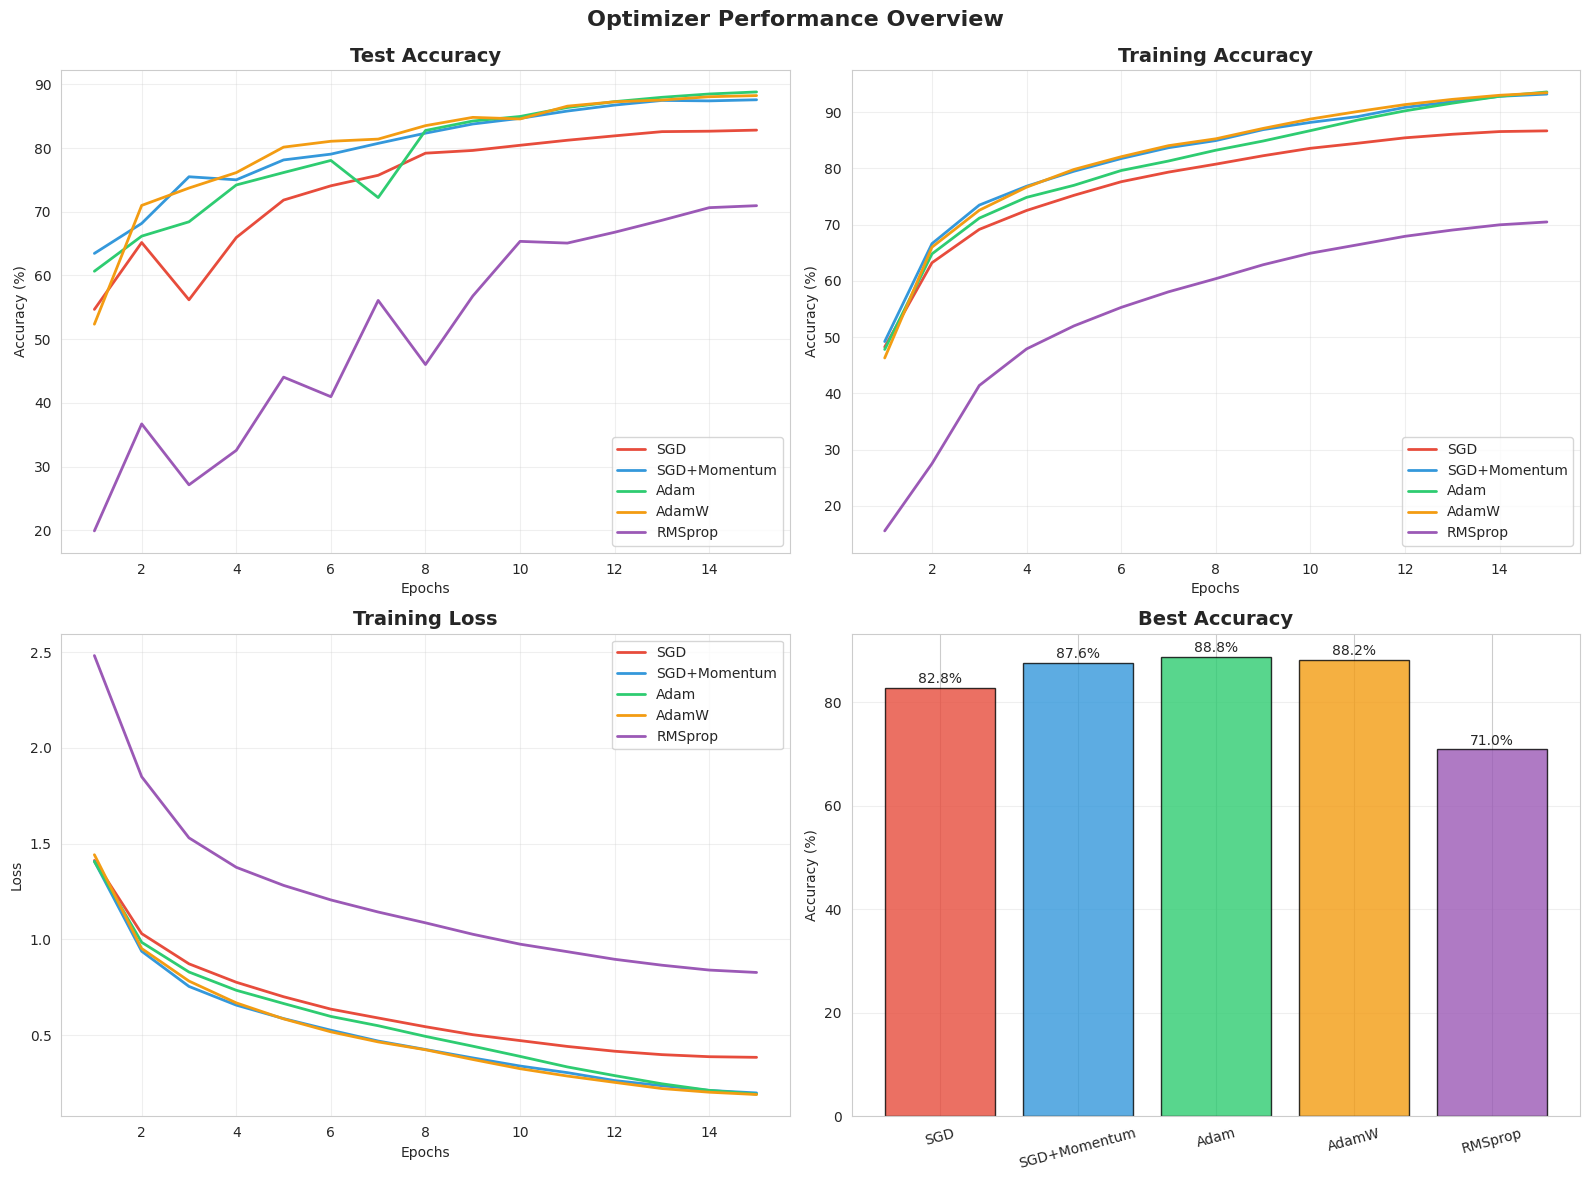

✅ Saved: optimizer_overview.png


In [28]:
# 创建组合图表（如果你还需要的话）
print("\nGenerating combined overview chart...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. 测试准确率
for opt, data in results.items():
    epochs = range(1, len(data['test_accuracies']) + 1)
    ax1.plot(epochs, data['test_accuracies'],
            label=opt_names[opt],
            color=colors[opt],
            linewidth=2)
ax1.set_title('Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 训练准确率
for opt, data in results.items():
    epochs = range(1, len(data['train_accuracies']) + 1)
    ax2.plot(epochs, data['train_accuracies'],
            label=opt_names[opt],
            color=colors[opt],
            linewidth=2)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 训练损失
for opt, data in results.items():
    epochs = range(1, len(data['train_losses']) + 1)
    ax3.plot(epochs, data['train_losses'],
            label=opt_names[opt],
            color=colors[opt],
            linewidth=2)
ax3.set_title('Training Loss', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Loss')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 最佳准确率
bars = ax4.bar(names, best_accs, color=colors_list, alpha=0.8, edgecolor='black')
ax4.set_title('Best Accuracy', fontsize=14, fontweight='bold')
ax4.set_ylabel('Accuracy (%)')
ax4.set_xticklabels(names, rotation=15)
ax4.grid(True, alpha=0.3, axis='y')

# 在柱子上添加数值
for bar, acc in zip(bars, best_accs):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Optimizer Performance Overview', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('optimizer_overview.png', dpi=300, bbox_inches='tight')
plt.savefig('optimizer_overview.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: optimizer_overview.png")

In [31]:
# 下载所有单独的图表
from google.colab import files

# 所有单独图表的文件列表
individual_charts = [
    'test_accuracy_comparison.png',
    'training_accuracy_comparison.png',
    'training_loss_comparison.png',
    'best_accuracy_comparison.png',
    'training_time_comparison.png',
    'final_vs_best_accuracy.png',
    'optimizer_overview.png'  # 组合图表（可选）
]

print("\nDownloading individual charts...")
for chart_file in individual_charts:
    try:
        files.download(chart_file)
        print(f"✅ Downloaded: {chart_file}")
    except:
        print(f"⚠️ Could not download: {chart_file}")

print("\n" + "="*60)
print("DOWNLOAD COMPLETE!")
print("="*60)
print("You now have 7 individual charts for your report:")
print("1. test_accuracy_comparison.png - Test accuracy over epochs")
print("2. training_accuracy_comparison.png - Training accuracy over epochs")
print("3. training_loss_comparison.png - Training loss over epochs")
print("4. best_accuracy_comparison.png - Bar chart of best accuracies")
print("5. training_time_comparison.png - Bar chart of training times")
print("6. final_vs_best_accuracy.png - Comparison of final vs best accuracy")
print("7. optimizer_overview.png - Combined overview (optional)")
print("\nYou can use these individually in your report as needed!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: test_accuracy_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: final_vs_best_accuracy.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: optimizer_overview.png

DOWNLOAD COMPLETE!
You now have 7 individual charts for your report:
1. test_accuracy_comparison.png - Test accuracy over epochs
2. training_accuracy_comparison.png - Training accuracy over epochs
3. training_loss_comparison.png - Training loss over epochs
4. best_accuracy_comparison.png - Bar chart of best accuracies
5. training_time_comparison.png - Bar chart of training times
6. final_vs_best_accuracy.png - Comparison of final vs best accuracy
7. optimizer_overview.png - Combined overview (optional)

You can use these individually in your report as needed!



Generating Advanced Analysis Charts...


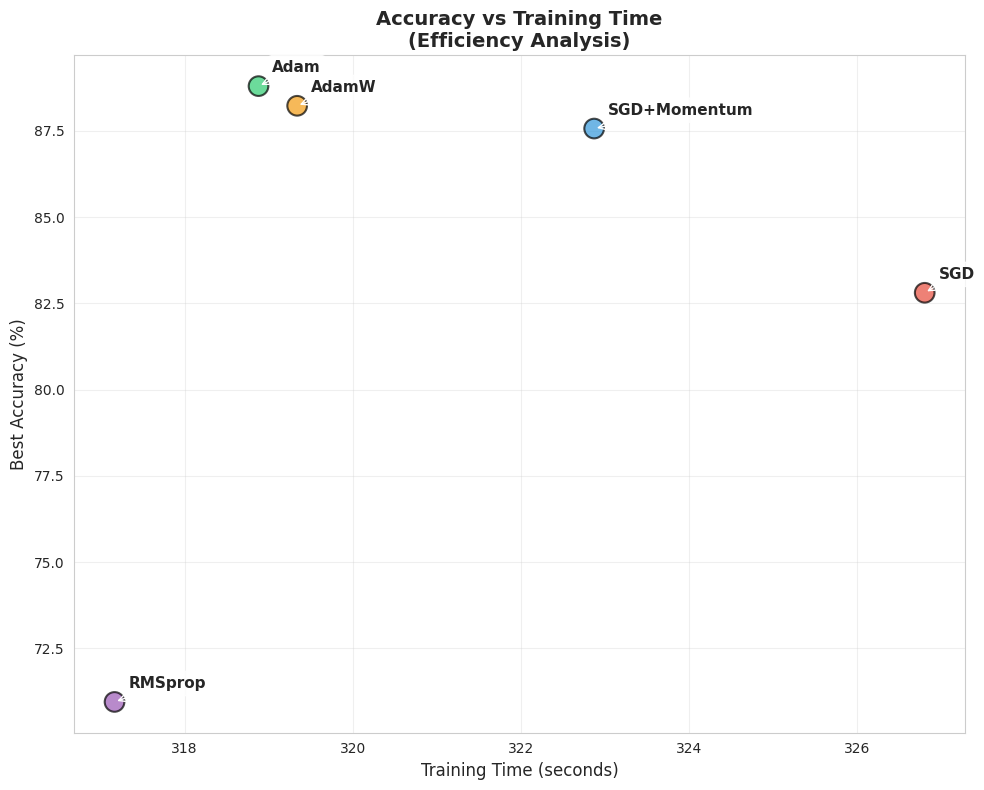

✅ Saved: efficiency_analysis.png


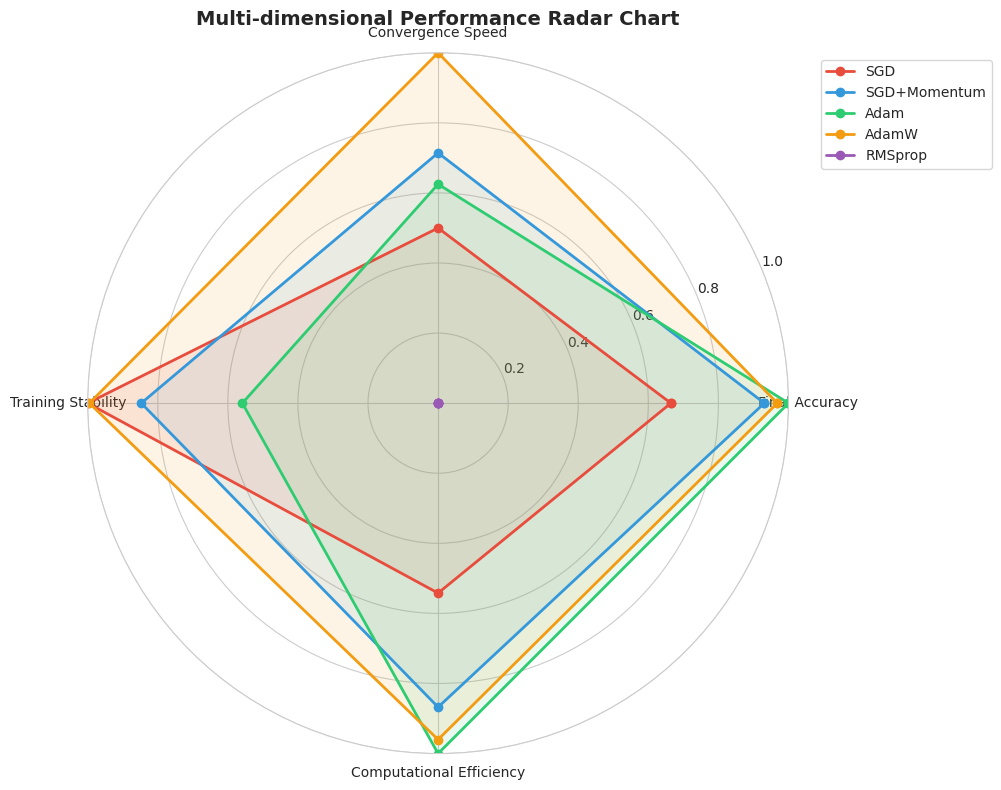

✅ Saved: performance_radar.png


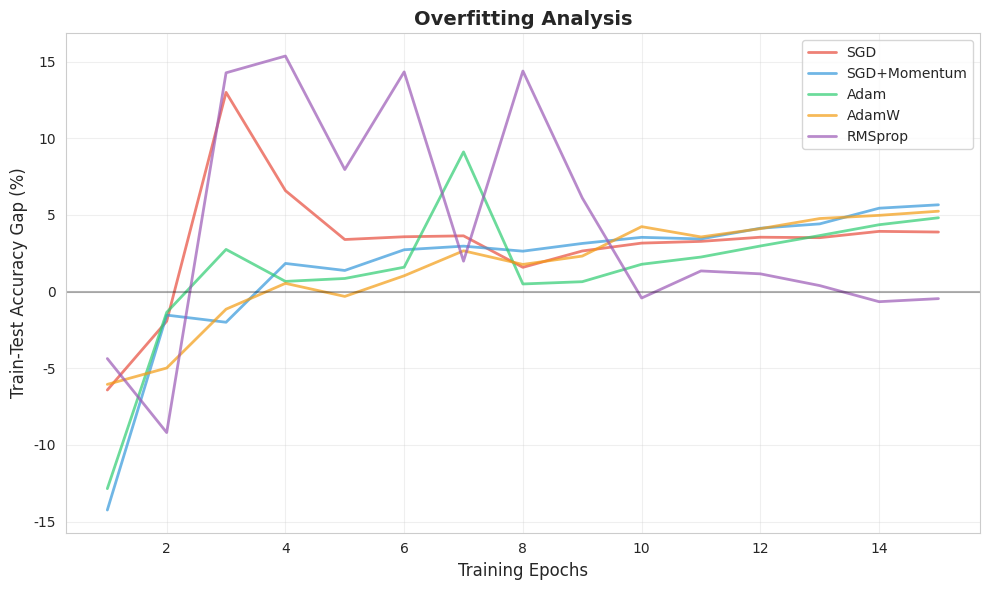

✅ Saved: overfitting_analysis.png


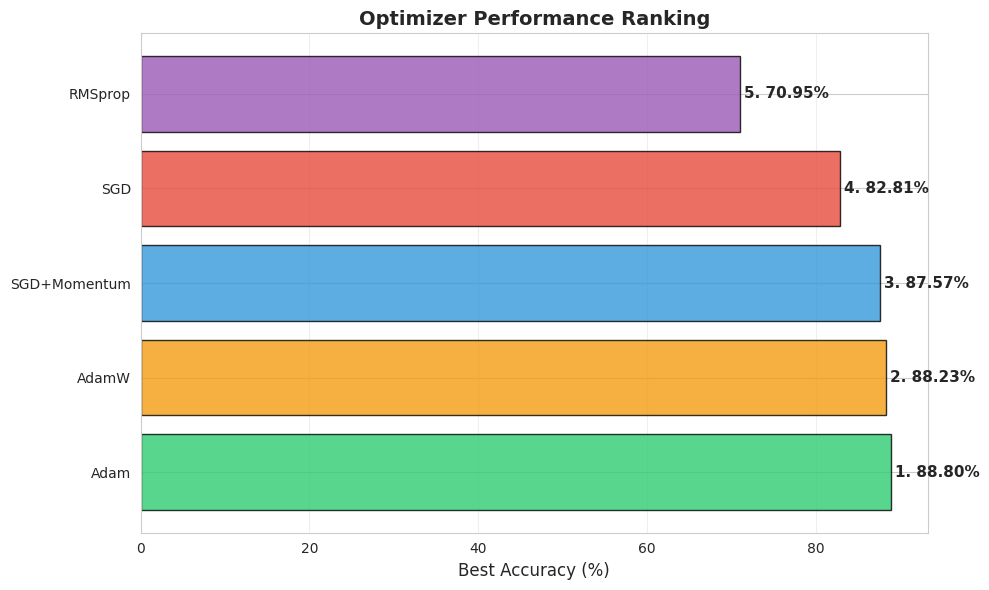

✅ Saved: performance_ranking.png


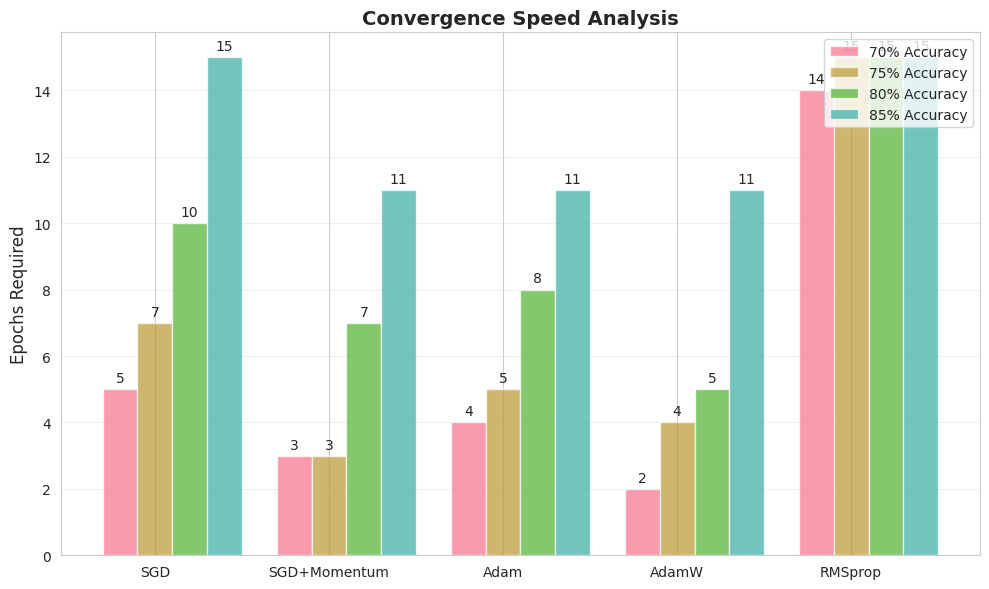

✅ Saved: convergence_speed.png


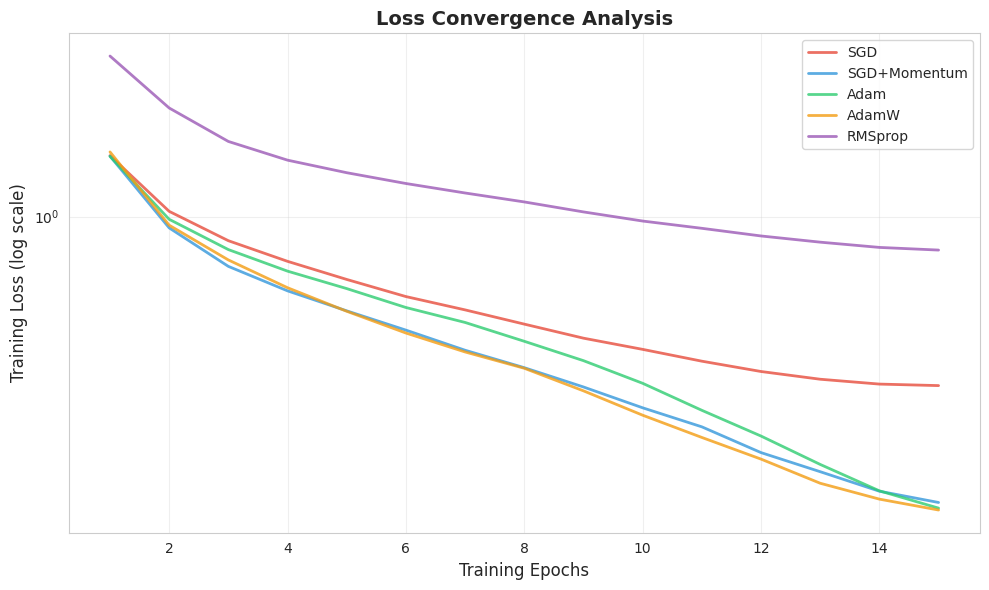

✅ Saved: loss_convergence.png


In [32]:
# 修复高级分析图表 - 单独生成每个图表
print("\nGenerating Advanced Analysis Charts...")

# 修复中文显示问题，全部使用英文
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. 准确率-时间散点图（效率对比）
plt.figure(figsize=(10, 8))
accuracies = [results[opt]['best_accuracy'] for opt in results.keys()]
times = [results[opt]['training_time'] for opt in results.keys()]
labels = [opt_names[opt] for opt in results.keys()]
colors_list = [colors[opt] for opt in results.keys()]

scatter = plt.scatter(times, accuracies, c=colors_list, s=200, alpha=0.7, edgecolors='black', linewidth=1.5)

# 添加标签
for i, label in enumerate(labels):
    plt.annotate(label, (times[i], accuracies[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"))

plt.xlabel('Training Time (seconds)', fontsize=12)
plt.ylabel('Best Accuracy (%)', fontsize=12)
plt.title('Accuracy vs Training Time\n(Efficiency Analysis)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficiency_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('efficiency_analysis.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: efficiency_analysis.png")

# 2. 相对性能雷达图
plt.figure(figsize=(10, 8))

# 计算各项指标（归一化到0-1）
categories = ['Final Accuracy', 'Convergence Speed', 'Training Stability', 'Computational Efficiency']
N = len(categories)

final_acc_norm = [results[opt]['test_accuracies'][-1]/100 for opt in results.keys()]

# 收敛速度：以达到80%准确率的轮次倒数作为指标
convergence_speed = []
for opt in results.keys():
    accuracies = results[opt]['test_accuracies']
    for i, acc in enumerate(accuracies):
        if acc >= 80:
            convergence_speed.append(1/(i+1))  # 轮次越少，速度越快
            break
    else:
        convergence_speed.append(0)  # 未达到80%

# 训练稳定性：以最后5个epoch准确率的标准差倒数作为指标
stability = []
for opt in results.keys():
    last_5_acc = results[opt]['test_accuracies'][-5:]
    if len(last_5_acc) > 1:
        stability.append(1/np.std(last_5_acc))
    else:
        stability.append(1)

# 计算效率：以准确率/时间的比值作为指标
efficiency = [results[opt]['best_accuracy']/results[opt]['training_time'] for opt in results.keys()]

# 归一化所有指标到0-1范围
def normalize(values):
    min_val, max_val = min(values), max(values)
    if max_val == min_val:
        return [0.5] * len(values)
    return [(v - min_val) / (max_val - min_val) for v in values]

final_acc_norm = normalize(final_acc_norm)
convergence_speed = normalize(convergence_speed)
stability = normalize(stability)
efficiency = normalize(efficiency)

# 绘制雷达图
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # 闭合图形

ax = plt.subplot(111, polar=True)
for i, opt in enumerate(results.keys()):
    values = [final_acc_norm[i], convergence_speed[i], stability[i], efficiency[i]]
    values += values[:1]  # 闭合图形
    ax.plot(angles, values, 'o-', linewidth=2, label=opt_names[opt], color=colors[opt])
    ax.fill(angles, values, alpha=0.1, color=colors[opt])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Multi-dimensional Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('performance_radar.png', dpi=300, bbox_inches='tight')
plt.savefig('performance_radar.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: performance_radar.png")

# 3. 过拟合程度分析图
plt.figure(figsize=(10, 6))
for opt, data in results.items():
    # 绘制训练和测试准确率的差异
    epochs = range(1, len(data['train_accuracies']) + 1)
    gap = [train - test for train, test in zip(data['train_accuracies'], data['test_accuracies'])]
    plt.plot(epochs, gap, label=opt_names[opt], color=colors[opt], linewidth=2, alpha=0.7)

plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Train-Test Accuracy Gap (%)', fontsize=12)
plt.title('Overfitting Analysis', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('overfitting_analysis.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: overfitting_analysis.png")

# 4. 性能排名柱状图
plt.figure(figsize=(10, 6))
# 按最佳准确率排序
sorted_opts = sorted(results.keys(), key=lambda x: results[x]['best_accuracy'], reverse=True)
sorted_names = [opt_names[opt] for opt in sorted_opts]
sorted_accs = [results[opt]['best_accuracy'] for opt in sorted_opts]
sorted_colors = [colors[opt] for opt in sorted_opts]

bars = plt.barh(sorted_names, sorted_accs, color=sorted_colors, alpha=0.8, edgecolor='black')

# 美化横向柱状图
plt.xlabel('Best Accuracy (%)', fontsize=12)
plt.title('Optimizer Performance Ranking', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# 在柱子上添加数值和排名
for i, (bar, acc) in enumerate(zip(bars, sorted_accs)):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{i+1}. {acc:.2f}%',
            va='center', ha='left',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_ranking.png', dpi=300, bbox_inches='tight')
plt.savefig('performance_ranking.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: performance_ranking.png")

# 5. 收敛速度分析图
plt.figure(figsize=(10, 6))
# 计算每个优化器达到不同准确率阈值所需的epoch数
thresholds = [70, 75, 80, 85]
threshold_data = {threshold: [] for threshold in thresholds}

for threshold in thresholds:
    for opt in results.keys():
        accuracies = results[opt]['test_accuracies']
        reached_epoch = None
        for i, acc in enumerate(accuracies):
            if acc >= threshold:
                reached_epoch = i + 1
                break
        threshold_data[threshold].append(reached_epoch if reached_epoch else len(accuracies))

x = np.arange(len(opt_names))
width = 0.2
multiplier = 0

for threshold, epochs in threshold_data.items():
    offset = width * multiplier
    rects = plt.bar(x + offset, epochs, width, label=f'{threshold}% Accuracy', alpha=0.7)
    plt.bar_label(rects, padding=3)
    multiplier += 1

plt.ylabel('Epochs Required', fontsize=12)
plt.title('Convergence Speed Analysis', fontsize=14, fontweight='bold')
plt.xticks(x + width, [opt_names[opt] for opt in results.keys()])
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('convergence_speed.png', dpi=300, bbox_inches='tight')
plt.savefig('convergence_speed.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: convergence_speed.png")

# 6. 损失收敛分析图
plt.figure(figsize=(10, 6))
for opt, data in results.items():
    epochs = range(1, len(data['train_losses']) + 1)
    plt.plot(epochs, data['train_losses'],
            label=opt_names[opt],
            color=colors[opt],
            linewidth=2,
            alpha=0.8)

plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Loss Convergence Analysis', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 检查是否使用对数坐标
all_losses = [loss for data in results.values() for loss in data['train_losses']]
max_loss = max(all_losses)
min_loss = min(all_losses)
if max_loss > 10 * min_loss and min_loss > 0:
    plt.yscale('log')
    plt.ylabel('Training Loss (log scale)')

plt.tight_layout()
plt.savefig('loss_convergence.png', dpi=300, bbox_inches='tight')
plt.savefig('loss_convergence.pdf', bbox_inches='tight')
plt.show()
print("✅ Saved: loss_convergence.png")

In [33]:
# 下载所有高级分析图表
from google.colab import files

# 高级分析图表文件列表
advanced_charts = [
    'efficiency_analysis.png',
    'performance_radar.png',
    'overfitting_analysis.png',
    'performance_ranking.png',
    'convergence_speed.png',
    'loss_convergence.png'
]

print("\nDownloading advanced analysis charts...")
for chart_file in advanced_charts:
    try:
        files.download(chart_file)
        print(f"✅ Downloaded: {chart_file}")
    except:
        print(f"⚠️ Could not download: {chart_file}")

print("\n" + "="*70)
print("ADVANCED ANALYSIS CHARTS DOWNLOAD COMPLETE!")
print("="*70)
print("You now have 6 advanced analysis charts:")
print("1. efficiency_analysis.png - Accuracy vs Training Time scatter plot")
print("2. performance_radar.png - Multi-dimensional performance radar chart")
print("3. overfitting_analysis.png - Overfitting analysis (train-test gap)")
print("4. performance_ranking.png - Optimizer performance ranking")
print("5. convergence_speed.png - Convergence speed analysis")
print("6. loss_convergence.png - Loss convergence analysis")
print("\nThese charts provide deeper insights into optimizer performance!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: efficiency_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: convergence_speed.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: loss_convergence.png

ADVANCED ANALYSIS CHARTS DOWNLOAD COMPLETE!
You now have 6 advanced analysis charts:
1. efficiency_analysis.png - Accuracy vs Training Time scatter plot
2. performance_radar.png - Multi-dimensional performance radar chart
3. overfitting_analysis.png - Overfitting analysis (train-test gap)
4. performance_ranking.png - Optimizer performance ranking
5. convergence_speed.png - Convergence speed analysis
6. loss_convergence.png - Loss convergence analysis

These charts provide deeper insights into optimizer performance!


In [35]:
# 创建完整的项目压缩包
import zipfile
import datetime

# 创建时间戳
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_filename = f'optimizer_comparison_project_{timestamp}.zip'

# 创建zip文件
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # 添加图表文件
    chart_files = [
        'test_accuracy_comparison.png', 'training_accuracy_comparison.png',
        'training_loss_comparison.png', 'best_accuracy_comparison.png',
        'training_time_comparison.png', 'final_vs_best_accuracy.png',
        'optimizer_overview.png', 'efficiency_analysis.png',
        'performance_radar.png', 'overfitting_analysis.png',
        'performance_ranking.png', 'convergence_speed.png',
        'loss_convergence.png'
    ]

    for file in chart_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ 已添加: {file}")

    # 添加结果文件
    result_files = [f'{opt}_results.json' for opt in ['sgd', 'sgd_momentum', 'adam', 'adamw', 'rmsprop']]
    for file in result_files:
        if os.path.exists(file):
            zipf.write(file)
            print(f"✅ 已添加: {file}")

    # 创建README文件
    readme_content = f"""
优化器对比实验项目包
生成时间: {timestamp}

包含内容:
1. 实验图表 (13个PNG文件)
2. 实验结果数据 (5个JSON文件)

实验设置:
- 数据集: CIFAR-10
- 模型: VGG11
- 优化器: SGD, SGD+Momentum, Adam, AdamW, RMSprop
- 训练轮次: 15 epochs

实验结果摘要:
- 最佳性能: Adam (88.80%)
- 良好性能: AdamW (88.23%), SGD+Momentum (87.57%)
- 较差性能: RMSprop (70.95%)

图表说明:
- test_accuracy_comparison.png: 测试准确率对比
- training_accuracy_comparison.png: 训练准确率对比
- training_loss_comparison.png: 训练损失对比
- best_accuracy_comparison.png: 最佳准确率柱状图
- training_time_comparison.png: 训练时间对比
- final_vs_best_accuracy.png: 最终vs最佳准确率
- optimizer_overview.png: 优化器性能概览
- efficiency_analysis.png: 效率分析散点图
- performance_radar.png: 多维度性能雷达图
- overfitting_analysis.png: 过拟合分析
- performance_ranking.png: 性能排名
- convergence_speed.png: 收敛速度分析
- loss_convergence.png: 损失收敛分析

用于: 人工智能课程期末报告
"""

    zipf.writestr('README.txt', readme_content)
    print("✅ 已添加: README.txt")

print(f"\n项目包已创建: {zip_filename}")
files.download(zip_filename)

✅ 已添加: test_accuracy_comparison.png
✅ 已添加: training_accuracy_comparison.png
✅ 已添加: training_loss_comparison.png
✅ 已添加: best_accuracy_comparison.png
✅ 已添加: training_time_comparison.png
✅ 已添加: final_vs_best_accuracy.png
✅ 已添加: optimizer_overview.png
✅ 已添加: efficiency_analysis.png
✅ 已添加: performance_radar.png
✅ 已添加: overfitting_analysis.png
✅ 已添加: performance_ranking.png
✅ 已添加: convergence_speed.png
✅ 已添加: loss_convergence.png
✅ 已添加: sgd_results.json
✅ 已添加: sgd_momentum_results.json
✅ 已添加: adam_results.json
✅ 已添加: adamw_results.json
✅ 已添加: rmsprop_results.json
✅ 已添加: README.txt

项目包已创建: optimizer_comparison_project_20251022_052534.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>